In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
from resources.Classes.Wave_function_class import *
from resources.Functions.system_fucntions import *
from matplotlib.colors import LogNorm
from resources.Classes.Simulation_Class import Simulation_Class
from resources.Classes.Wave_vector_class import Wave_vector_class
from resources.Classes.Nbody_classes.Baryonic_N_body import Baryons
from resources.Classes.Nbody_classes.NBodyGas import NBodyGas
from resources.Classes.Nbody_classes.Sink_N_Body import SinkNBody

In [3]:
KM_S_TO_KPC_GYR = 1.0227121650537077  # 1 km/s in kpc/Gyr



In [4]:
m_scalar_eV = 1e-22
HBAR_TILDE = 19.60695038367394

MBH = 1e6

boundaries = [[-25, 25], [-25, 25], [-25, 25]]

sim = Simulation_Class(
    dim=3,
    boundaries=boundaries,
    N=640,
    total_time=5.0,
    h=1e-3,
    order_of_evolution=2,
    use_gravity=True,
    static_potential=None,
    save_max_vals=True,
    self_int=False,
    use_sponge=True,
    m_s=m_scalar_eV,
)

hbartilde 19.60695038367394


In [29]:
Mstar = 4.43973553668394e9   # Msun
a_star = 1.0                 # kpc
r_trunc_star = 7.0           # kpc
sigma_kms = 20.0             # km/s
sigma = sigma_kms * KM_S_TO_KPC_GYR

Mdisk = 2e8

stellar_disk = Baryons(
    simulation=sim,
    N_particles=int(8e4),
    total_mass=Mdisk,
    init_profile="disk",
    radius=6.0,                 # larger disk scale
    center=(0.0, 0.0, 0.0),
    velocity=(0.0, 0.0, 0.0),
    vel_sigma=8.0,
    height=0.7,                 # thicker
    circular_velocity=55.0,     # km/s
)
sim.add_baryons(stellar_disk)

Mbulge = 5e7
a_bulge = 1.2
r_trunc_bulge = 5.0
sigma_bulge_kms = 25.0
sigma_bulge = sigma_bulge_kms * KM_S_TO_KPC_GYR

bulge = Baryons(
    simulation=sim,
    N_particles=int(3e4),
    total_mass=Mbulge,
    init_profile="hernquist",
    scale_radius=a_bulge,
    truncation_radius=r_trunc_bulge,
    center=(0.0, 0.0, 0.0),
    velocity=(0.0, 0.0, 0.0),
    vel_sigma=sigma_bulge,
)
sim.add_baryons(bulge)

In [30]:
sink = SinkNBody(
    simulation=sim,
    N_sinks=1,
    initial_masses=[MBH],
    initial_positions=[[0.0, 0.0, 0.0]],
    initial_velocities=[[0.0, 0.0, 0.0]],
    capture_radius=4.0 * min(sim.dx),
    softening_length=2.0 * min(sim.dx),
)
sim.add_baryons(sink)

In [12]:
N = sim.N
x, y, z = sim.grids
x = np.array(x)
y = np.array(y)
z = np.array(z)

R = np.sqrt(x**2 + y**2)
Z = np.abs(z)

Mgas = 5e7      # lighter
R0 = 8.0        # more extended
Z0 = 0.8        # thicker

rho_shape = np.exp(-R / R0) * np.exp(-Z / Z0)

rho_floor = 1e-12
rho = rho_shape + rho_floor
rho = np.maximum(rho, rho_floor)

M_current = rho.sum() * sim.dV
rho *= (Mgas / M_current)

v0_kms = 45.0
v0 = v0_kms * KM_S_TO_KPC_GYR
Rcore = 2.5
vphi = v0 * R / np.sqrt(R**2 + Rcore**2)

eps = 1e-12
vx = -vphi * (y / (R + eps))
vy =  vphi * (x / (R + eps))
vz = np.zeros_like(vx)

cs_kms = 18.0
cs = cs_kms * KM_S_TO_KPC_GYR

gas = NBodyGas(
    simulation=sim,
    rho=rho,
    vx=vx,
    vy=vy,
    vz=vz,
    name="gas",
    cs=cs,
    gamma=5/3,
    tcool=None,
    e_floor=1e-10,
    rho_floor=rho_floor,
    cfl=0.4,
)
sim.add_baryons(gas)

In [32]:
def halo_mass_from_Mbh(Mbh_Msun):
    logMbh = np.log10(Mbh_Msun)
    logMhalo = 13.0 + (logMbh - 8.18)/1.55
    return 10**logMhalo

def soliton_mass_pred_from_Mbh(Mbh_Msun, m_eV):
    Mhalo = halo_mass_from_Mbh(Mbh_Msun)
    m_sol = 1.25e9 * (Mhalo/1e12)**(1/3) * (m_eV/1e-22)**(-1)
    return m_sol,Mhalo


Msol_target = soliton_mass_pred_from_Mbh(MBH, m_scalar_eV)[0]
Mhalo = soliton_mass_pred_from_Mbh(MBH, m_scalar_eV)[1]
print(Msol_target)
print(Mhalo)

915010635.4630874
392236845126.2703


In [5]:
wave_vector = Wave_vector_class(
    packet_type="resources/solitons/GroundState(1).dat",
    means=[0.0, 0.0, 0.0],
    st_deviations=[1.2, 1.2, 1.2],
    simulation=sim,
    mass=1,
    omega=1,
    momenta=[0.0, 0.0, 0.0],
    spin=1,
    desired_soliton_mass=331812960,
)


print(wave_vector.wave_vector[0].soliton_radius)
print(wave_vector.wave_vector[0].soliton_mass_radius)
Msol = wave_vector.wave_vector[0].soliton_mass
Msol_dyn0 = wave_vector.wave_vector[0].soliton_dynamic_mass
sim.add_wave_vector(wave_vector)

/home/smidmar9/.local/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


passed mass is 331812960
passed mass is 331812960
calculated mass is 331812960.0
1.0
above is lambda
11.8
331813937.5 sol massss
dynamic mass 329409375.0
0.6987712429686843
1.012615734126228
existuju někdy tady?
{1: [<resources.Classes.Wave_function_class.Wave_function object at 0x7fa32c67cd10>, <resources.Classes.Wave_function_class.Wave_function object at 0x7fa32e54a390>, <resources.Classes.Wave_function_class.Wave_function object at 0x7fa32e54a1d0>]}
tohle končím s len 3 <resources.Classes.Wave_vector_class.Wave_vector_class object at 0x7fa2d4529b10>
a nejspíš bych měl pracovat s len 1 {1: [<resources.Classes.Wave_function_class.Wave_function object at 0x7fa32c67cd10>, <resources.Classes.Wave_function_class.Wave_function object at 0x7fa32e54a390>, <resources.Classes.Wave_function_class.Wave_function object at 0x7fa32e54a1d0>]}


In [ ]:
print(wave_vector.wave_vector[0].soliton_dynamic_mass)
sim.evolve(save_every=250)

329409375.0
pracuji s len 3 functions: [<resources.Classes.Wave_function_class.Wave_function object at 0x7fa32c67cd10>, <resources.Classes.Wave_function_class.Wave_function object at 0x7fa32e54a390>, <resources.Classes.Wave_function_class.Wave_function object at 0x7fa32e54a1d0>]

Maximum allowed time step: 6.605852604637082e-05
  - From dispersion relation: 0.00013211705209274164
  - From potential term: 1231941025692.9924


Do you want to continue with the current time step anyway? (y/n):  y


Continuing with user-specified time step despite stability concerns.
Mass: 331814462.82445836
Deviation [%]: 231.81446282445836
mass diff is -1.000000 Msun


Simulation Progress:   0%|          | 0/5000 [00:00<?, ?step/s]

starting evolution
is first


Simulation Progress:   0%|          | 8/5000 [01:32<6:26:31,  4.65s/step]  

In [12]:
observed_mass_drop = Msol_dyn0 - sim.wave_functions[0].calculate_dynamic_core_mass()
print(Msol_dyn0)
print(observed_mass_drop)
print(wave_vector.wave_vector[0].calculate_dynamic_core_mass()) 
print(sink.total_accreted_mass)
print(sink.masses[0])


25989248.474121094
101209.82705741376
25888038.64706368
0.0
30000000.0


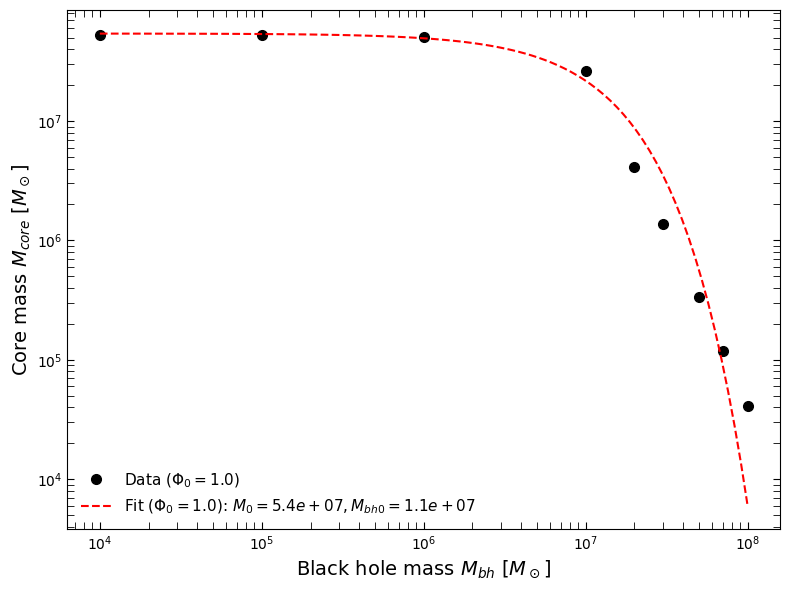

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_fit(M_bh, M_0, M_bh0, beta):
    return M_0 * np.exp(-M_bh / M_bh0)

#files = [
#    ("soliton_radii_data_ms2522_phi0_5.csv", "0.5", "s", "royalblue", "dodgerblue"),
#    ("soliton_radii_data_ms2522_phi1.csv", "1.0", "o", "black", "red"),
#    ("soliton_radii_data_ms2522_phi1_5.csv", "1.5", "x", "green", "orange"),
#]
files = [("resources/solitons/phi1/soliton_data_ms2522_phi1.csv", '1.0', 'o', 'black', 'red')]

plt.figure(figsize=(8, 6))
fit_parameters = {}

for file, phi, mk, c_data, c_fit in files:
    df = pd.read_csv(file).sort_values(by='M_bh')
    plt.plot(df['M_bh'], df['Msol'], marker=mk, ms=7, color=c_data, ls='', label=fr'Data ($\Phi_0 = {phi}$)')
    
    if len(df) >= 3:
        p0 = [df['Msol'].max(), 5e6, 1.0]
        popt, _ = curve_fit(exp_fit, df['M_bh'], df['Msol'], p0=p0, bounds=(0, np.inf), maxfev=10000)
        fit_parameters[phi] = popt
        
        x_fit = np.logspace(np.log10(df['M_bh'].min()), np.log10(df['M_bh'].max()), 100)
        y_fit = exp_fit(x_fit, *popt)
        
        eq = fr'Fit ($\Phi_0={phi}$): $M_0={popt[0]:.1e}, M_{{bh0}}={popt[1]:.1e}$'
        plt.plot(x_fit, y_fit, color=c_fit, ls='--', lw=1.5, label=eq)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Black hole mass $M_{bh} \ [M_\odot]$', fontsize=14)
plt.ylabel(r'Core mass $M_{core} \ [M_\odot]$', fontsize=14)
plt.tick_params(axis='both', which='both', direction='in', length=5, right=True, top=True)
plt.legend(fontsize=11, frameon=False)
plt.tight_layout()
plt.show()
#plt.savefig("plots/soliton_masses/Msol_evolution_on_Mbh_25e-22.png", format='png', dpi=600, bbox_inches='tight')
def predict_soliton_mass_drop(M_bh_start, M_bh_end, M_0, M_bh0):
    M_core_start = M_0 * np.exp(-M_bh_start / M_bh0)
    M_core_end = M_0 * np.exp(-M_bh_end / M_bh0)

    return M_core_start - M_core_end

In [14]:
mass_drop_predicted = predict_soliton_mass_drop(MBH/10,sink.masses[0],5.4e7,1.1e7)
print(observed_mass_drop)
print( mass_drop_predicted)
print(MBH, sink.masses[0], eq)
print(float(observed_mass_drop - mass_drop_predicted))

101209.82705741376
45775978.90482971
10000000.0 30000000.0 Fit ($\Phi_0=1.0$): $M_0=5.4e+07, M_{bh0}=1.1e+07$
-45674769.0777723


In [ ]:
import csv
import os
import pandas as pd

csv_filename = "resources/solitons/phi1/soliton_mass_drop_phi1.csv"

m_bh_start = float(MBH)
m_bh_end = float(sink.masses[0])
m_core_start = float(Msol) 
obs_drop = float(observed_mass_drop)
pred_drop = float(mass_drop_predicted)

file_exists = os.path.isfile(csv_filename)

with open(csv_filename, mode='a', newline='') as file:
    writer = csv.writer(file)
    

    if not file_exists:
        writer.writerow([
            'M_bh_start', 
            'M_bh_end', 
            'm_scalar_eV', 
            'Mhalo', 
            'M_core_start', 
            'Observed_mass_drop', 
            'Predicted_mass_drop'
        ])
        print(f"Vytvořen nový soubor: {csv_filename} a zapsána hlavička.")
        

    writer.writerow([
        m_bh_start, 
        m_bh_end, 
        m_scalar_eV, 
        Mhalo, 
        m_core_start, 
        obs_drop, 
        pred_drop
    ])

# Zobrazení tabulky pro kontrolu
display(pd.read_csv(csv_filename))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Nastavení vědeckého vzhledu (patkové písmo jako v článcích)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Načtení dat
df = pd.read_csv("soliton_radii_data_ms2522_phi0_5.csv")
df = df.sort_values(by='M_bh')

plt.figure(figsize=(7, 5))

# Samotná data - POUZE body (linestyle='none')
plt.plot(df['M_bh'], df['Msol'], marker='o', markersize=6, color='black', 
         linestyle='none', label=r'Simulation data ($\Phi_0 = 1$)')

# Hledání scaling relation (fit pro BH doménu)
df_bh_dominated = df[df['M_bh'] >= 5e6]

if len(df_bh_dominated) >= 2:
    log_Mbh = np.log10(df_bh_dominated['M_bh'])
    log_Mcore = np.log10(df_bh_dominated['Msol'])
    
    B, log_A = np.polyfit(log_Mbh, log_Mcore, 1)
    A = 10**log_A
    
    # Křivka fitu - červená přerušovaná čára
    plt.plot(df_bh_dominated['M_bh'], A * df_bh_dominated['M_bh']**B, color='red', 
             linestyle='--', linewidth=1.5, label=fr'Fit: $M_{{core}} \propto M_{{bh}}^{{{B:.2f}}}$')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Black hole mass $M_{bh} \ [M_\odot]$', fontsize=13)
plt.ylabel(r'Core mass $M_{core} \ [M_\odot]$', fontsize=13)

# Typické vědecké ticky (směřují dovnitř, jsou i na pravé a horní ose)
plt.tick_params(axis='both', which='major',  length=6, width=1, labelsize=11, right=True, top=True)
plt.tick_params(axis='both', which='minor',  length=3, width=1, right=True, top=True)

# Legenda bez ohraničení
plt.legend(fontsize=11, frameon=False, loc='best')

plt.tight_layout()
plt.show()

if len(df_bh_dominated) >= 2:
    print(f"Scaling relation: M_core = {A:.2e} * M_bh ^ {B:.4f}")

In [30]:
import os
import csv
import pandas as pd 


csv_filename = "resources/solitons/phi1/soliton_data_ms2522_phi1.csv"
r_sol = wave_vector.wave_vector[0].soliton_radius
r_mass_sol =wave_vector.wave_vector[0].soliton_mass_radius
file_exists = os.path.isfile(csv_filename)

with open(csv_filename, mode='a', newline='') as file:
    writer = csv.writer(file)
    if not file_exists:
        writer.writerow(['M_bh', 'm_scalar_eV', 'Mhalo', 'Msol_target','Msol', 'soliton_radius','soliton_mass_radius'])
        print(f"Vytvořen nový soubor: {csv_filename}")
        
    writer.writerow([MBH, m_scalar_eV, Mhalo ,Msol_target,Msol, r_sol,r_mass_sol])
    print(f"Uloženo: M_bh={MBH:.2e}, m_s={m_scalar_eV},Mhalo ={Mhalo:.2e} ,M_sol={Msol_target:.2e}, r_sol={r_sol:.4f},r_mass={r_mass_sol:.4f}")


display(pd.read_csv(csv_filename))

Uloženo: M_bh=1.00e+08, m_s=2.5e-22,Mhalo =7.65e+12 ,M_sol=9.85e+08, r_sol=0.0000,r_mass=0.0000


,M_bh,m_scalar_eV,Mhalo,Msol_target,Msol,soliton_radius,soliton_mass_radius
0,1000000.0,2.500000e-22,3.922368e+11,3.660043e+08,5.014554e+07,0.662913,1.048157
1,100000.0,2.500000e-22,8.879471e+10,2.230655e+08,5.279384e+07,0.110941,0.000000
2,10000.0,2.500000e-22,2.010138e+10,1.359498e+08,5.306043e+07,0.182950,0.182950
3,10000000.0,2.500000e-22,1.732645e+12,6.005372e+08,2.637849e+07,0.020590,0.000000
4,30000000.0,2.500000e-22,3.519896e+12,7.605830e+08,1.386103e+06,0.000854,0.000000
5,50000000.0,2.500000e-22,4.893934e+12,8.488990e+08,3.333214e+05,0.000184,0.000000
6,70000000.0,2.500000e-22,6.080429e+12,9.126020e+08,1.196755e+05,0.000061,0.000000
7,20000000.0,2.500000e-22,2.709709e+12,6.970718e+08,4.110817e+06,0.002764,0.000000
8,100000000.0,2.500000e-22,7.653692e+12,9.853571e+08,4.130362e+04,0.000020,0.000000


In [8]:
N = sim.N
x, y, z = sim.grids
x = np.array(x); y = np.array(y); z = np.array(z)

Mgas = 1e7  

rho = np.ones_like(x)

M_current = rho.sum() * sim.dV
rho *= (Mgas / M_current)

rho_floor = 1e-12
rho = np.maximum(rho, rho_floor)

# 3. Plyn bude na začátku v absolutním klidu
vx = np.zeros_like(x)
vy = np.zeros_like(x)
vz = np.zeros_like(x)


cs_kms = 120.0  
cs = cs_kms * KM_S_TO_KPC_GYR

# A dál už normálně voláš NBodyGas...
gas = NBodyGas(
    simulation=sim,
    rho=rho,
    vx=vx,
    vy=vy,
    vz=vz,
    cs=cs,
    gamma=5/3,
    tcool=None,
    e_floor=1e-10,
    rho_floor=rho_floor,
    cfl=0.8,
    max_substeps=200
)
sim.add_baryons(gas)

In [15]:
print(predicted)
print(observed)

[10376748.18670372]
[array(21125104.63027102)]


pracuji s len 1 functions: [<resources.Classes.Wave_function_class.Wave_function object at 0x7ff9013045d0>]

Maximum allowed time step: 0.00014863168360433436
  - From dispersion relation: 0.0002972633672086687
  - From potential term: 4927764102771.97


Do you want to continue with the current time step anyway? (y/n):  y


Continuing with user-specified time step despite stability concerns.
Single particle detected: Trajectory tracking enabled.
Mass: 8540488696.316562
Deviation [%]: 8440.488696316563
mass diff is -0.999607 Msun


Simulation Progress:   0%|          | 0/2000 [00:00<?, ?step/s]

starting evolution
is first


Simulation Progress: 100%|██████████| 2000/2000 [13:42<00:00,  2.43step/s]  

is last


[Scribe] Warning: could not save baryon snapshot at time 1.000000: 'list' object has no attribute 'deposit_to_grid'
Energy log saved to: resources/data/simulation_20260226_132910/energy.txt
resources/data/max_values.csv saved


Should I plot these values? (y/n/del):  y


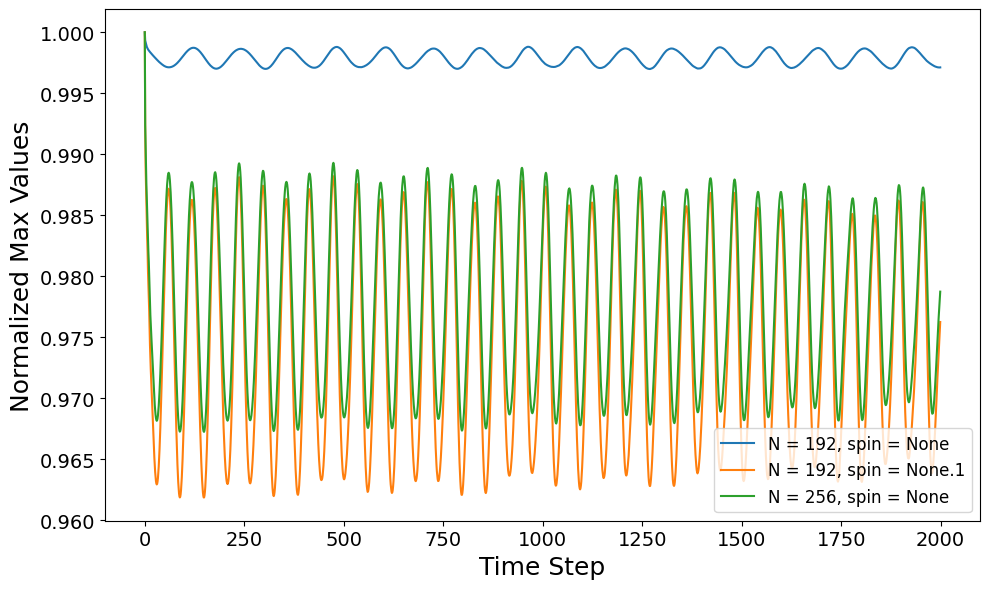

Evolution completed successfully
Saved times are [0, 0.0, 0.1245, 0.249, 0.3735, 0.498, 0.6225, 0.747, 0.8715, 0.996, 1]


In [87]:

sim.evolve(save_every=249)

In [13]:
predicted = []
observed = []

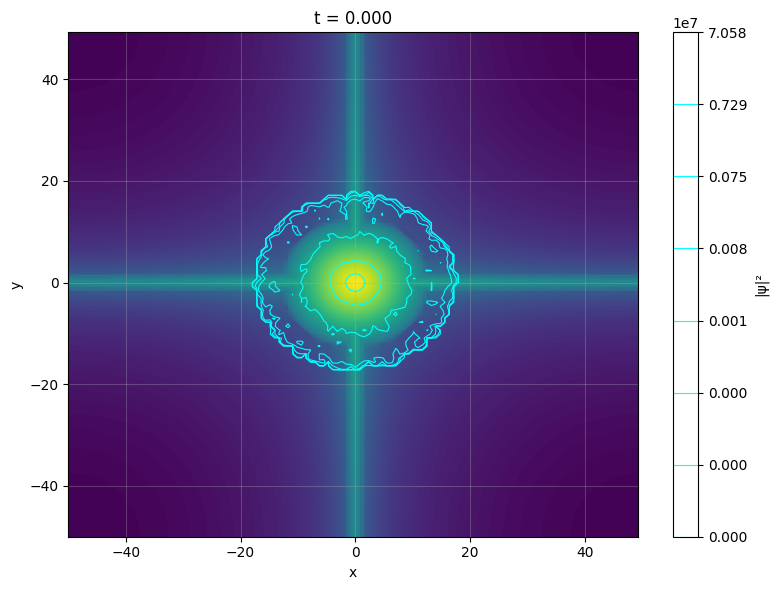

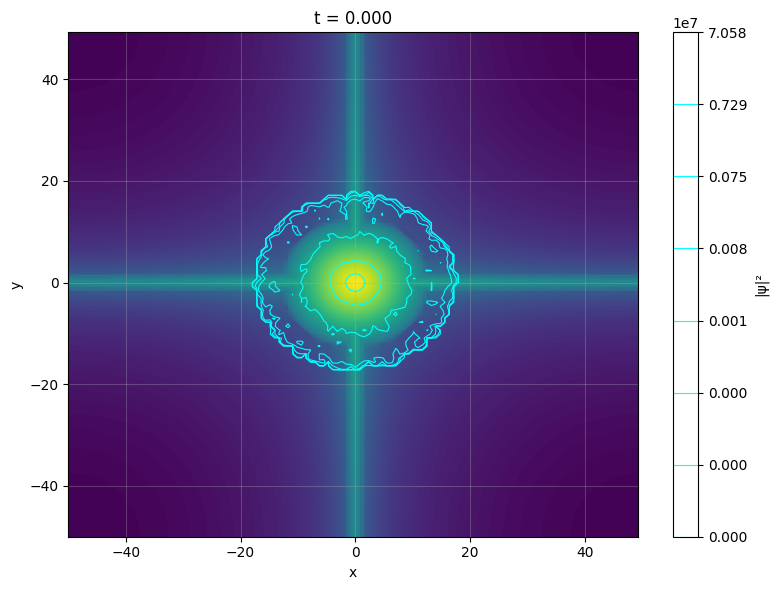

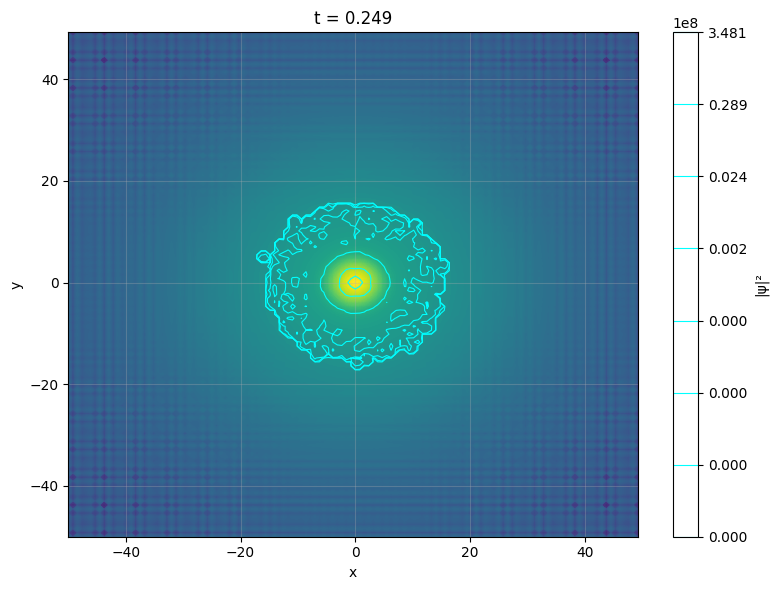

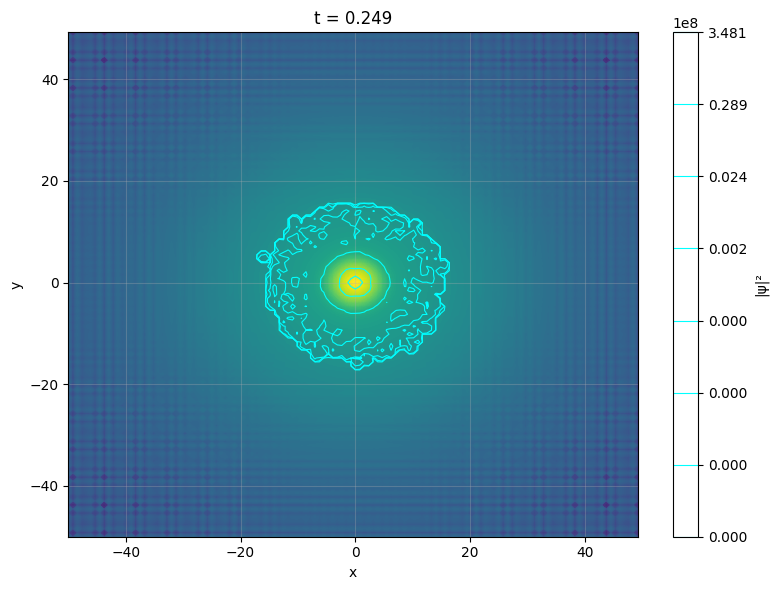

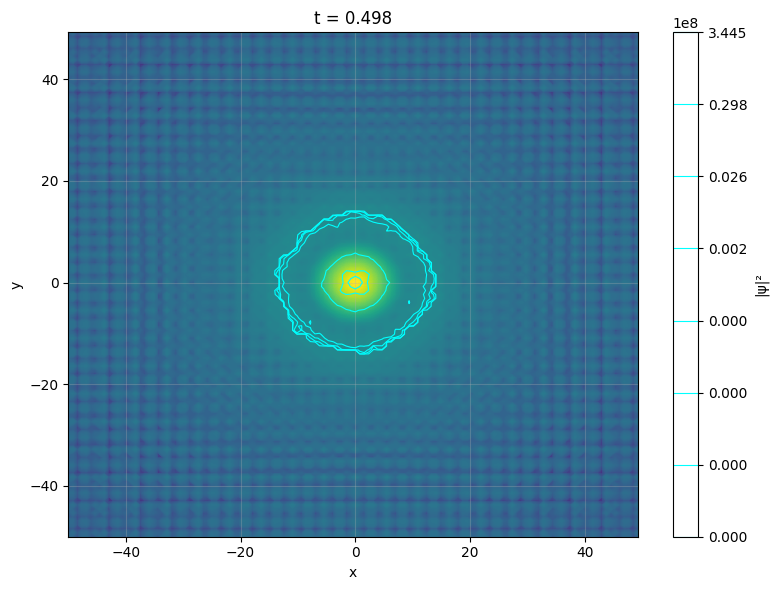

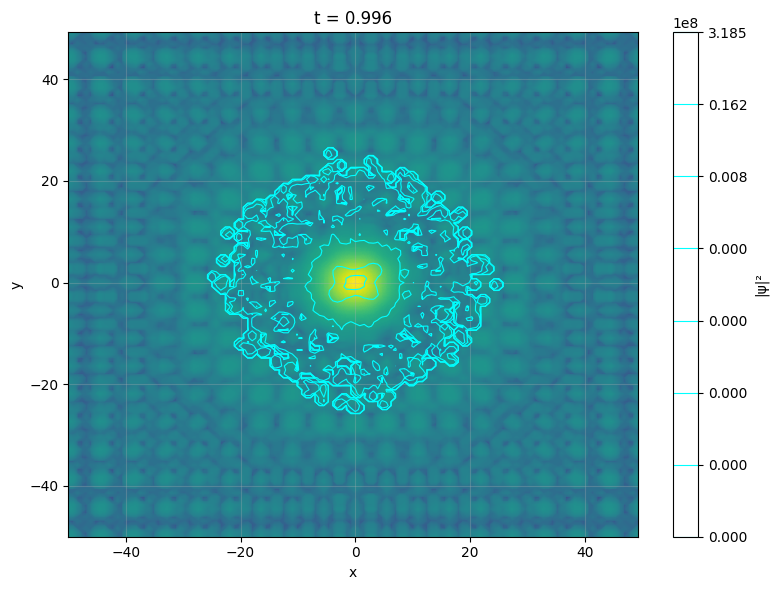

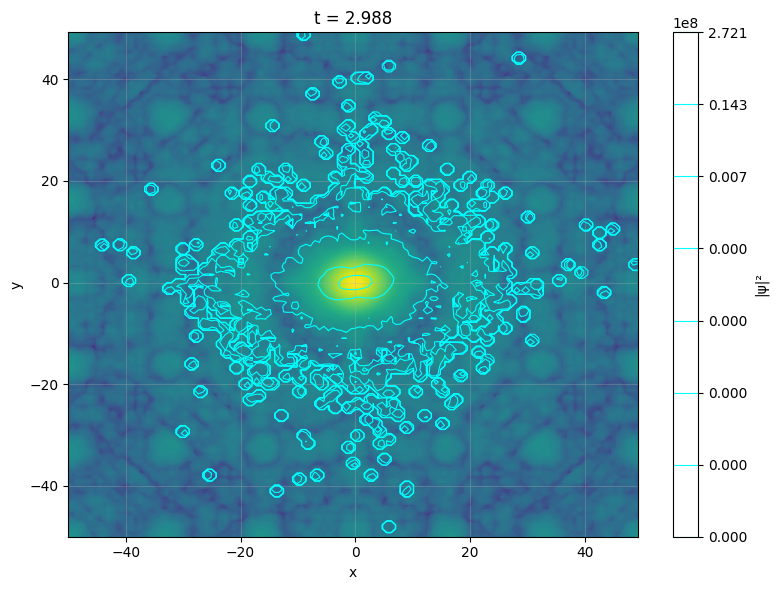

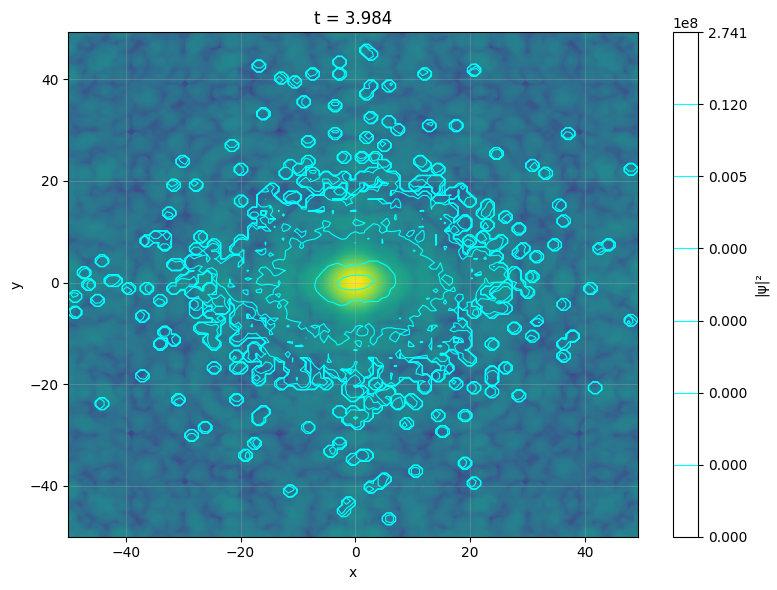

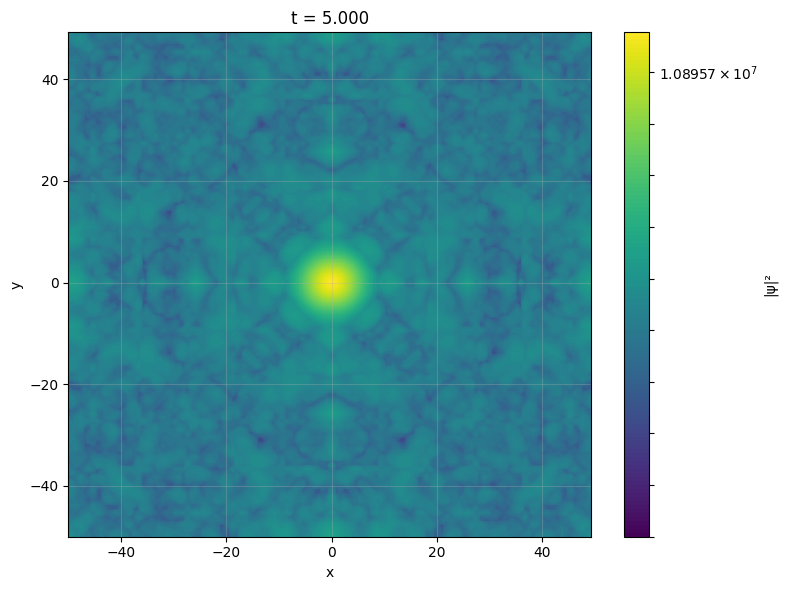

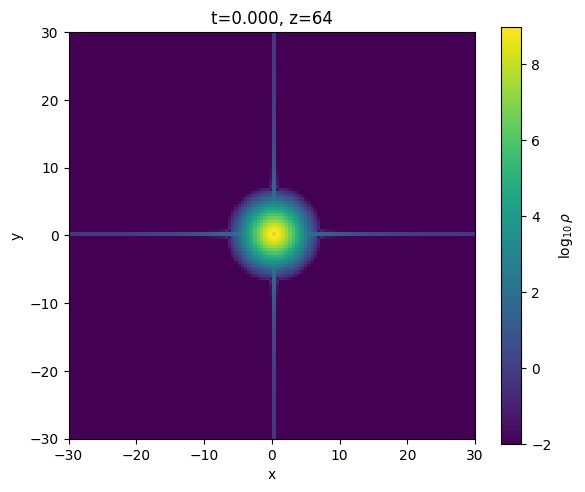

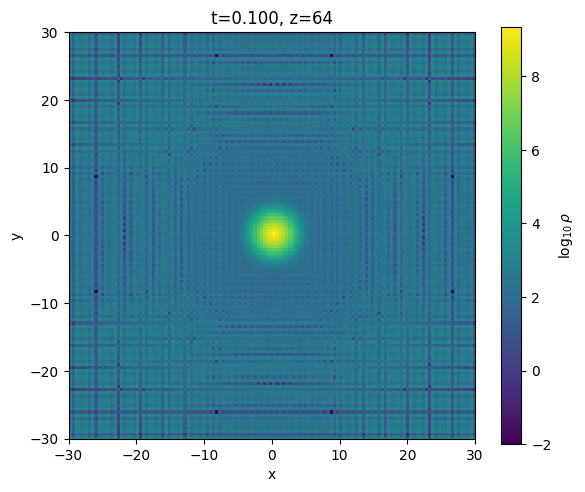

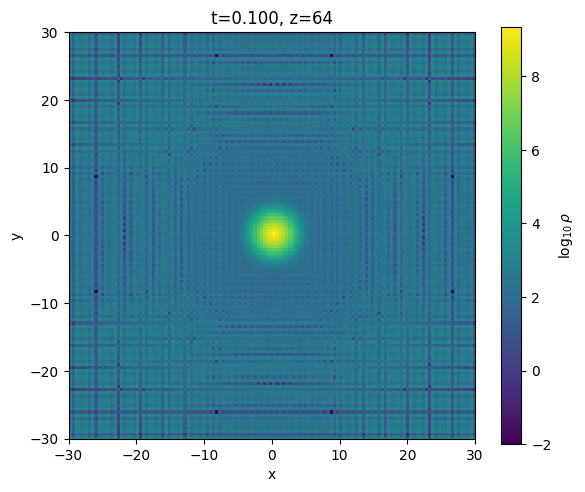

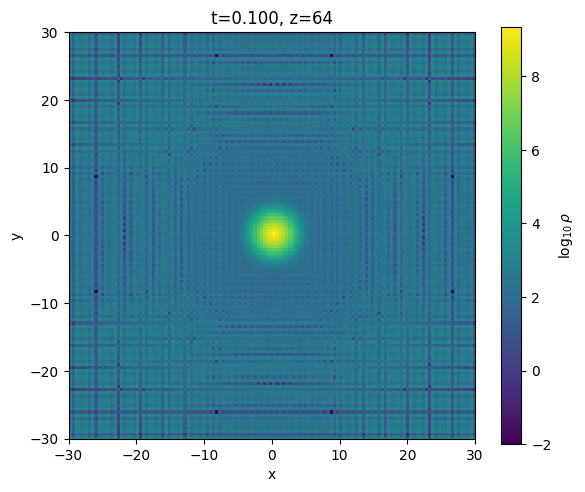

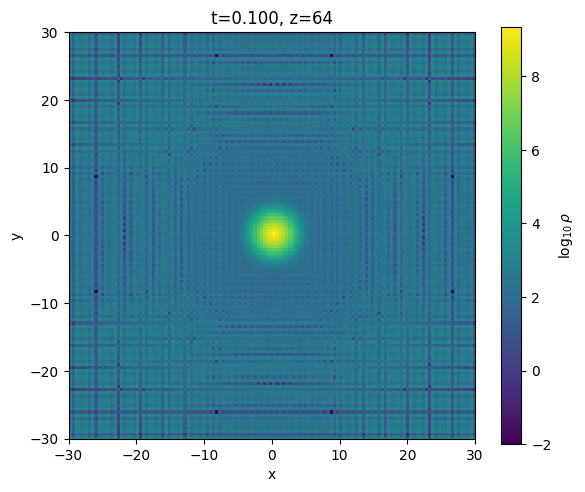

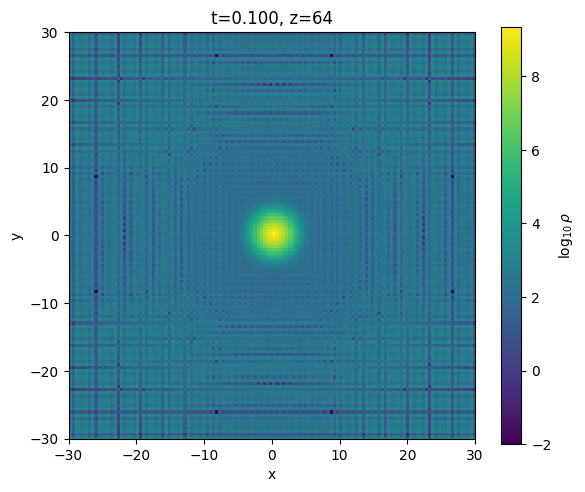

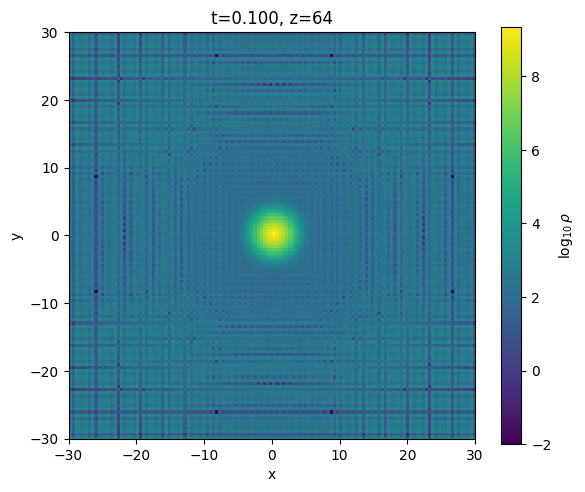

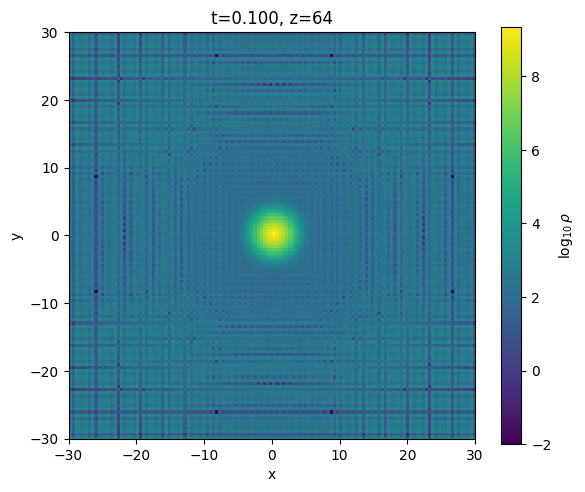

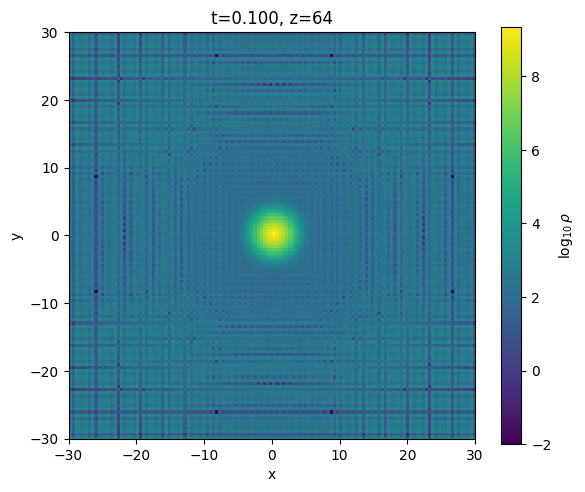

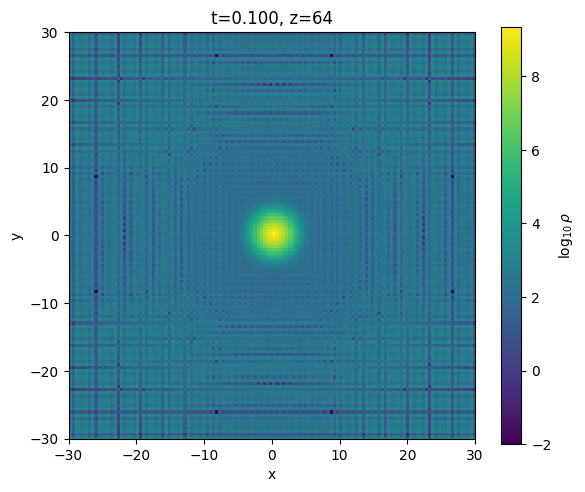

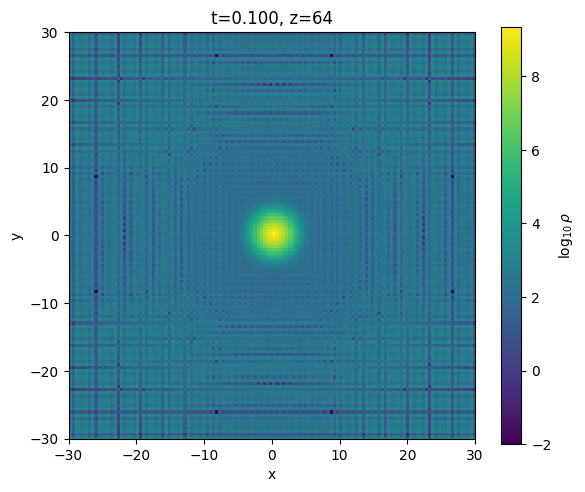

a


<Figure size 640x480 with 0 Axes>

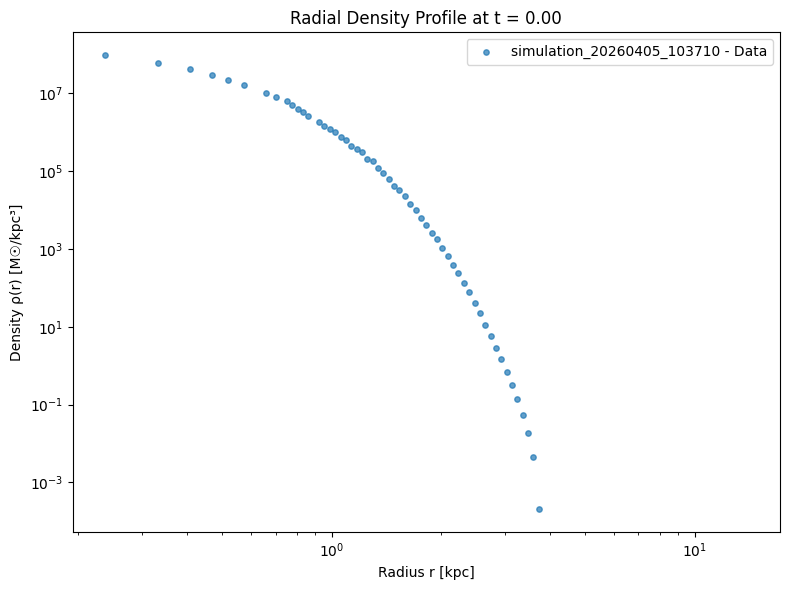

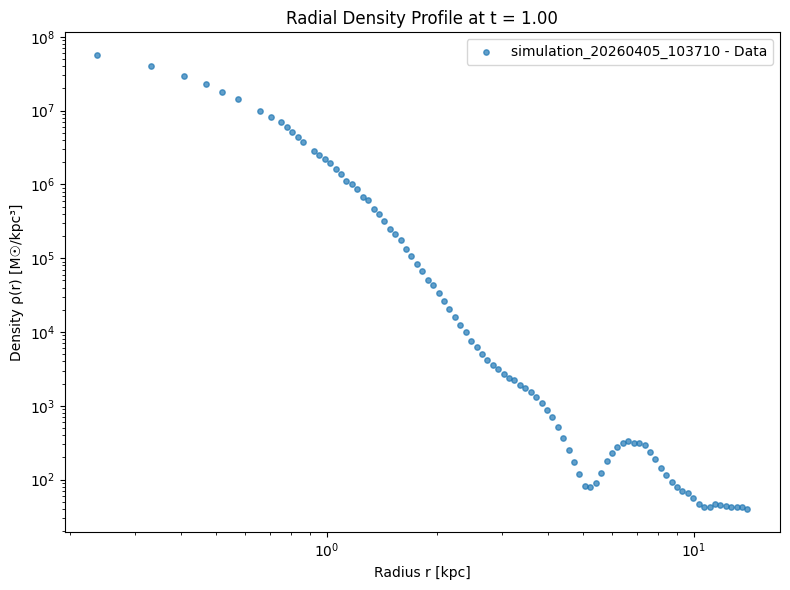

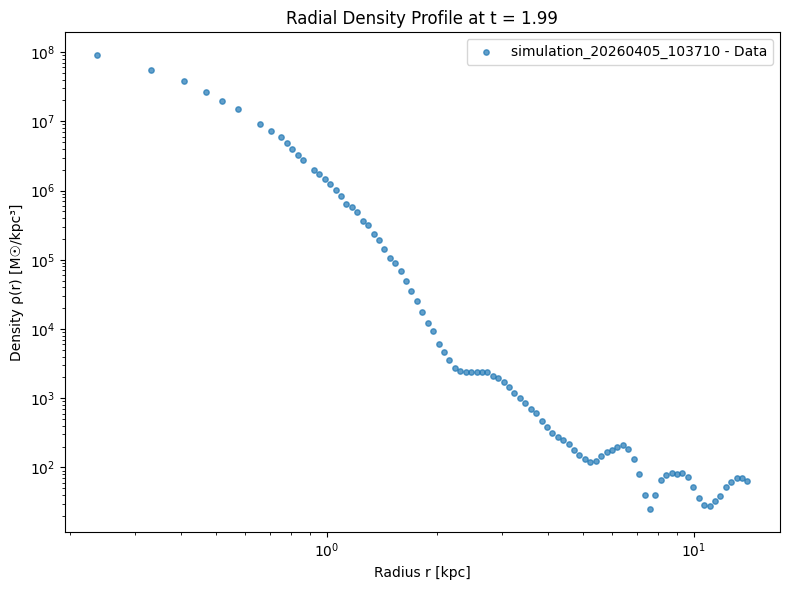

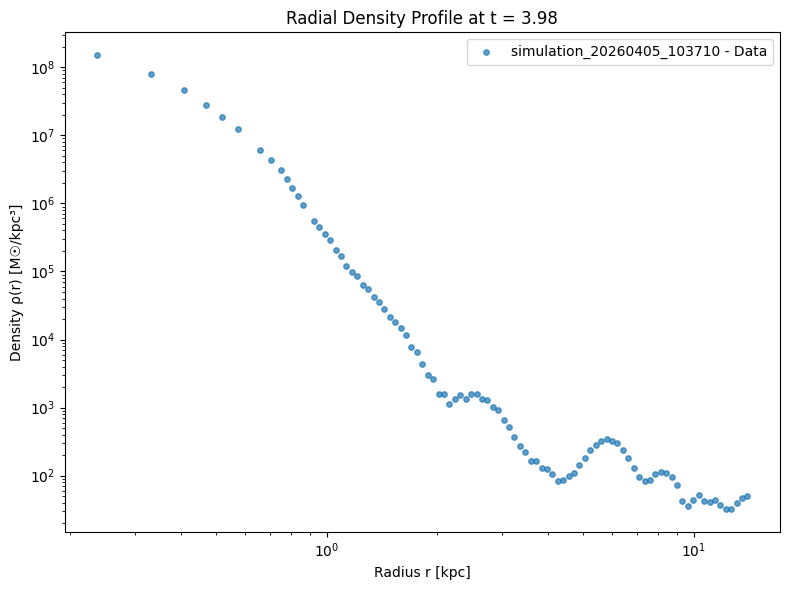

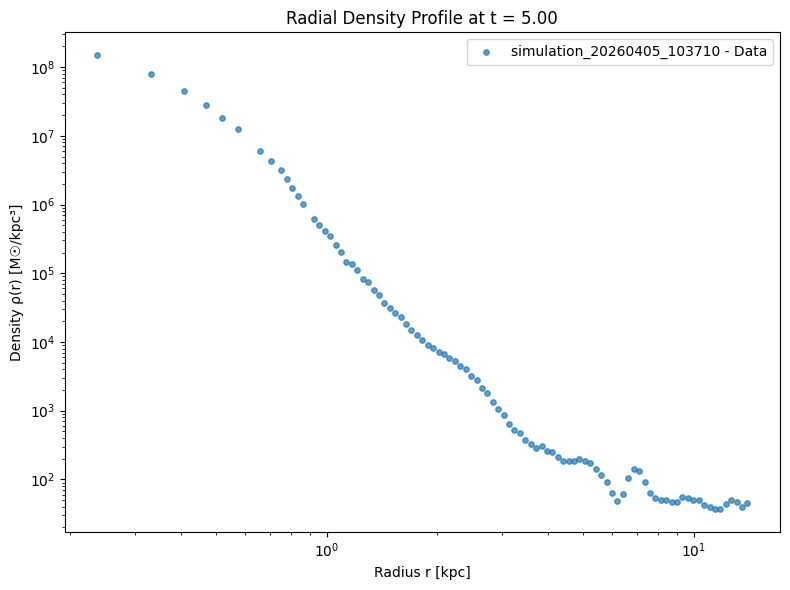

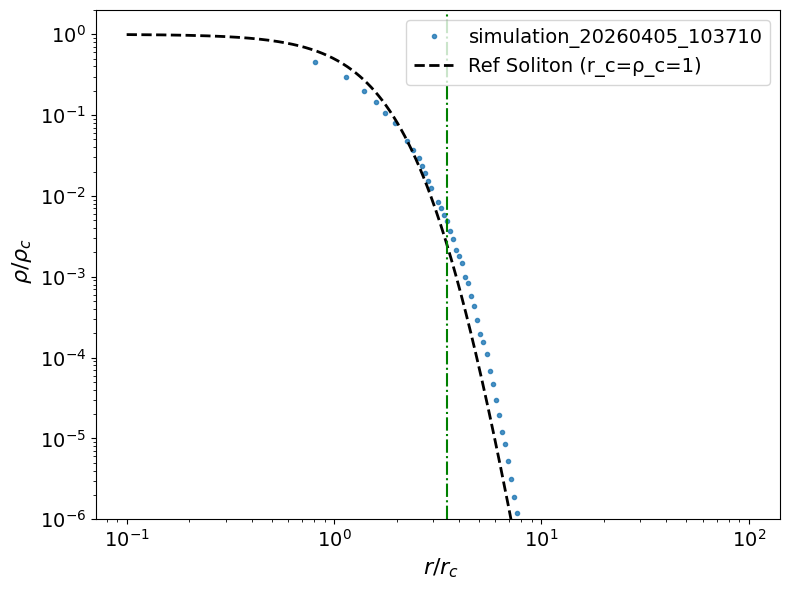

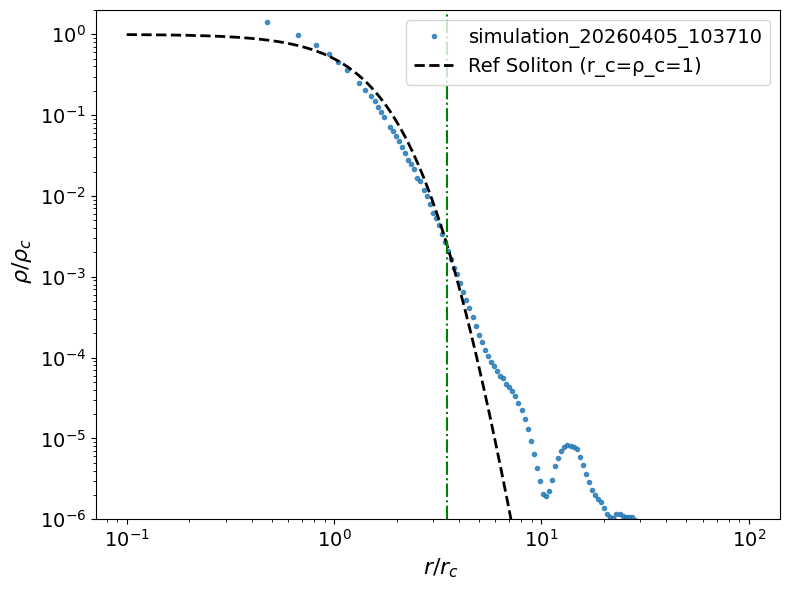

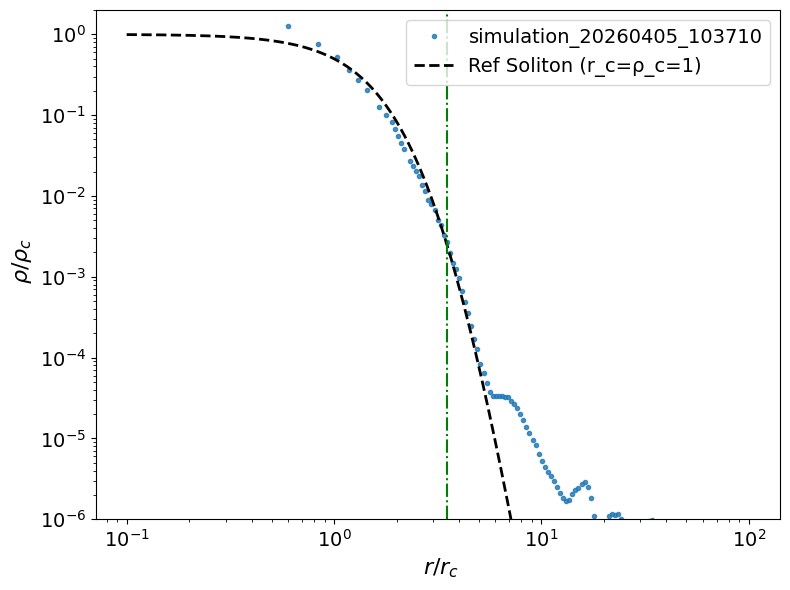

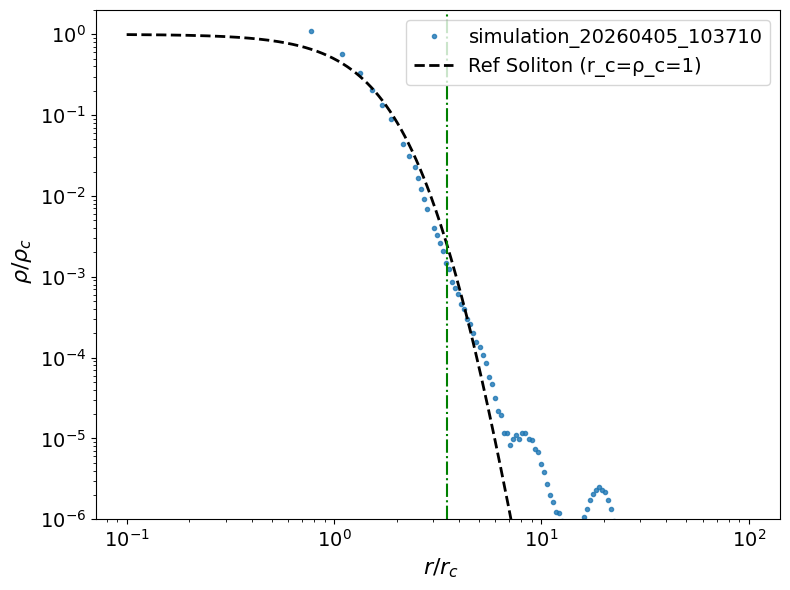

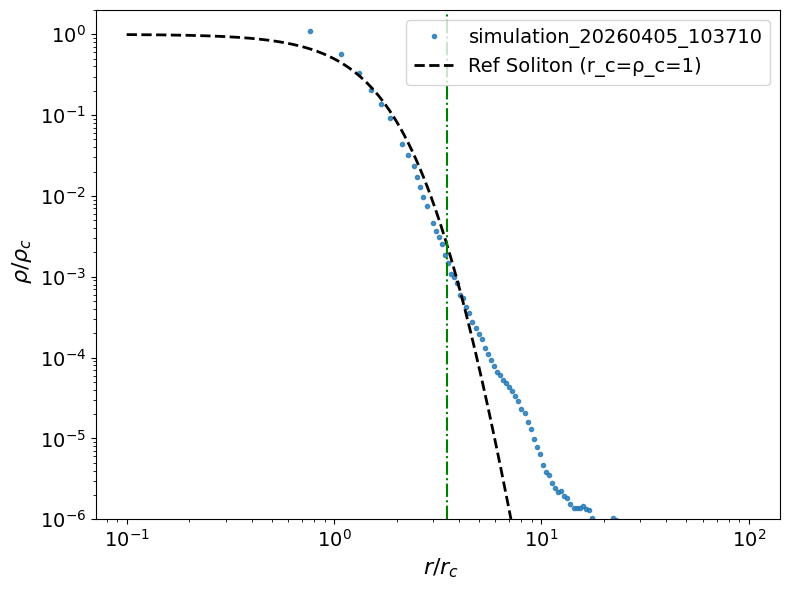

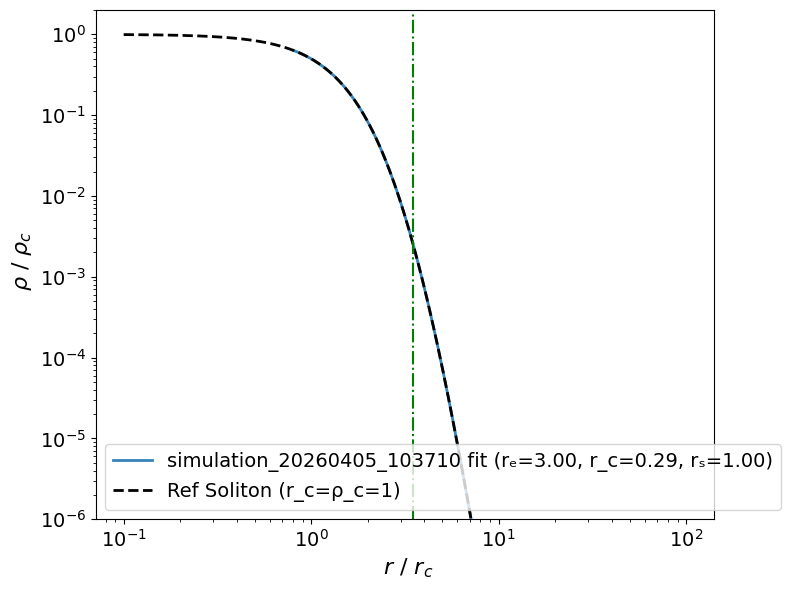

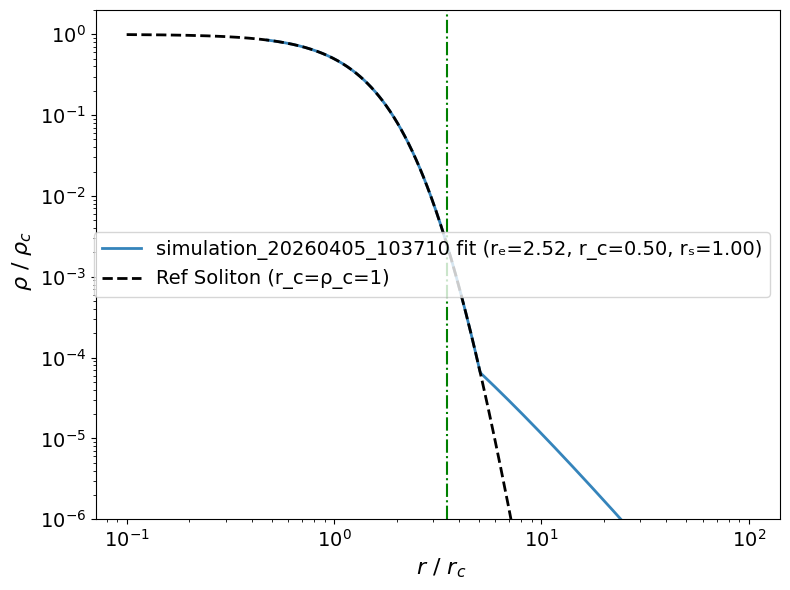

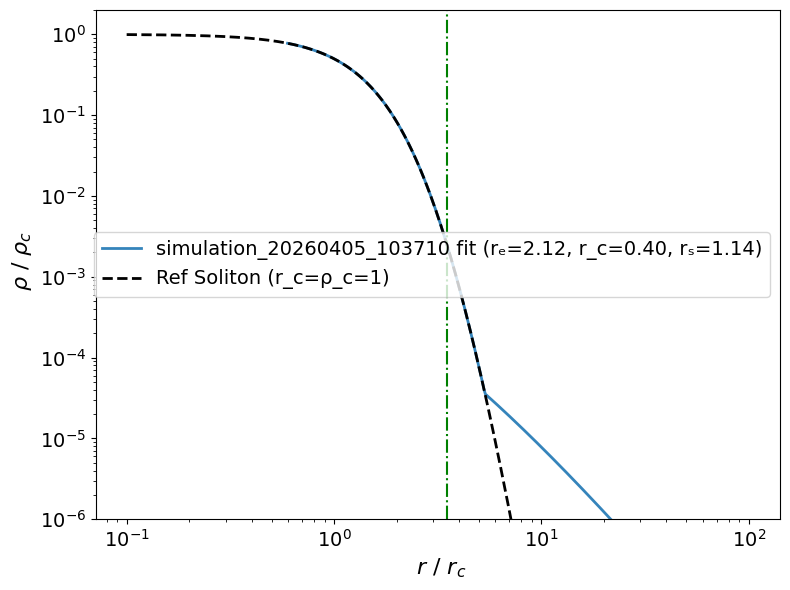

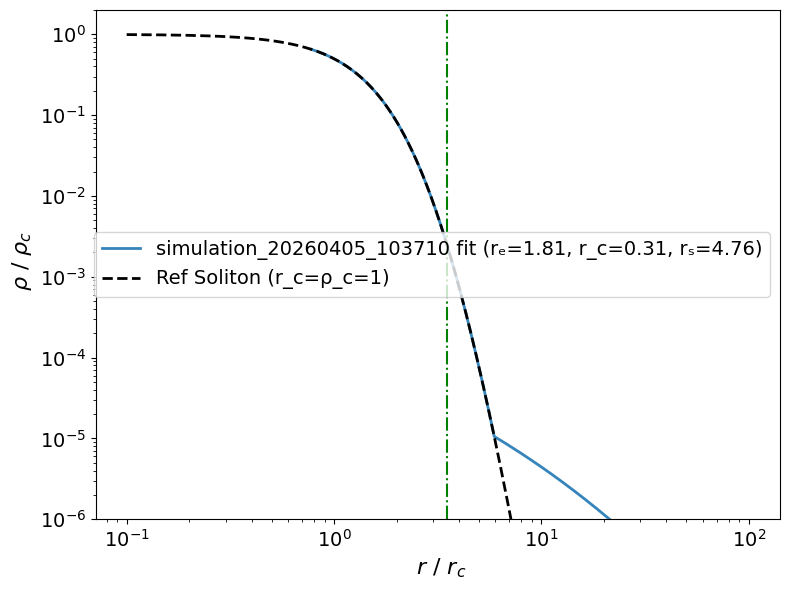

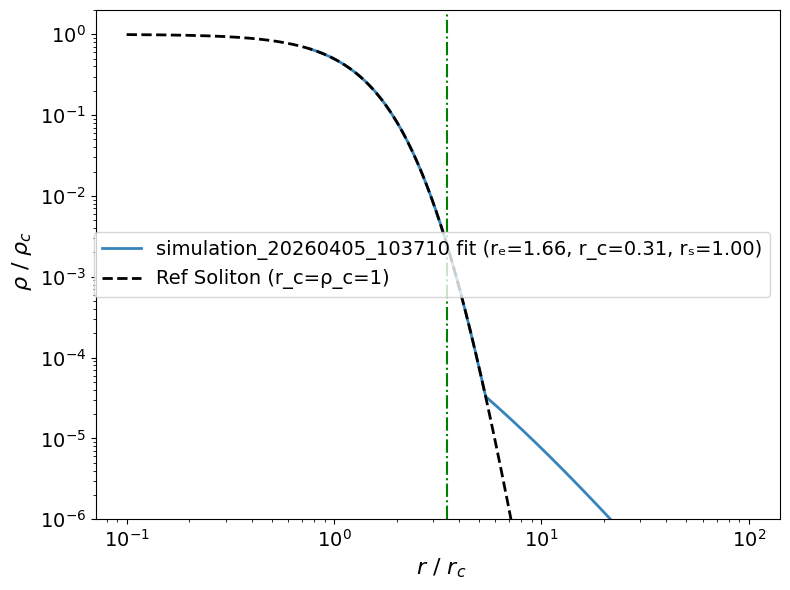

<Figure size 640x480 with 0 Axes>

In [30]:
%matplotlib inline
%run plot_from_snapshots.py
#%run Plot_max_vals.py
%run plot_density.py

Uloženo: M_bh=5.00e+07, m_s=2.5e-22,Mhalo =4.89e+12 ,M_sol=8.49e+08, r_sol=0.0001,r_mass=0.0000


,M_bh,m_scalar_eV,Mhalo,Msol_target,Msol,soliton_radius,soliton_mass_radius
0,100000000.0,2.500000e-22,7.653692e+12,9.853571e+08,41303.61,0.000010,0.0
1,50000000.0,2.500000e-22,4.893934e+12,8.488990e+08,333321.25,0.000092,0.0


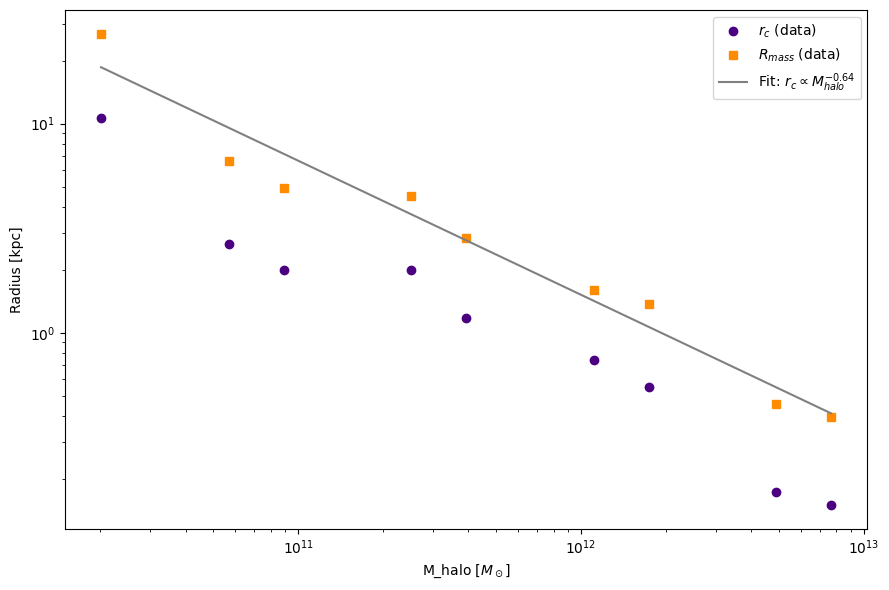

fit: R_mass = 7.45e+07 * M_halo ^ -0.6409


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("soliton_radii_data.csv")
df = df.sort_values(by='Mhalo')

# Fitování v log-log prostoru pro r_c (log R = B * log M + log A)
log_M = np.log10(df['Mhalo'])
log_R = np.log10(df['soliton_mass_radius'])
B, log_A = np.polyfit(log_M, log_R, 1)
A = 10**log_A

plt.figure(figsize=(9, 6))

# ls='' odstraní čáry mezi body
plt.plot(df['Mhalo'], df['soliton_radius'], marker='o', ls='', color='indigo', label='$r_c$ (data)')
plt.plot(df['Mhalo'], df['soliton_mass_radius'], marker='s', ls='', color='darkorange', label='$R_{mass}$ (data)')

# Vykreslení proložené přímky
plt.plot(df['Mhalo'], A * df['Mhalo']**B, color='gray', ls='-', label=f'Fit: $r_c \propto M_{{halo}}^{{{B:.2f}}}$')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('M_halo [$M_\odot$]')
plt.ylabel('Radius [kpc]')
plt.legend()
plt.tight_layout()

plt.show()

# Výpis nalezeného vztahu
print(f"fit: R_mass = {A:.2e} * M_halo ^ {B:.4f}")

Opravená tabulka:


,M_bh,m_scalar_eV,Mhalo,Msol_target,soliton_radius,soliton_mass_radius
0,10000.0,2.500000e-23,2.010138e+10,1.359498e+09,10.673652,26.902984
1,50000.0,2.500000e-23,5.677723e+10,1.921740e+09,2.659344,6.609137
2,500000.0,2.500000e-23,2.508046e+11,3.153178e+09,1.996000,4.518637
3,100000.0,2.500000e-23,8.879471e+10,2.230655e+09,2.003363,4.907218
4,1000000.0,2.500000e-23,3.922368e+11,3.660043e+09,1.176831,2.834185
5,5000000.0,2.500000e-23,1.107890e+12,5.173712e+09,0.742849,1.604738
6,10000000.0,2.500000e-23,1.732645e+12,6.005372e+09,0.549444,1.373610
7,50000000.0,2.500000e-23,4.893934e+12,8.488990e+09,0.172458,0.456282
8,100000000.0,2.500000e-23,7.653692e+12,9.853571e+09,0.149835,0.396426


a


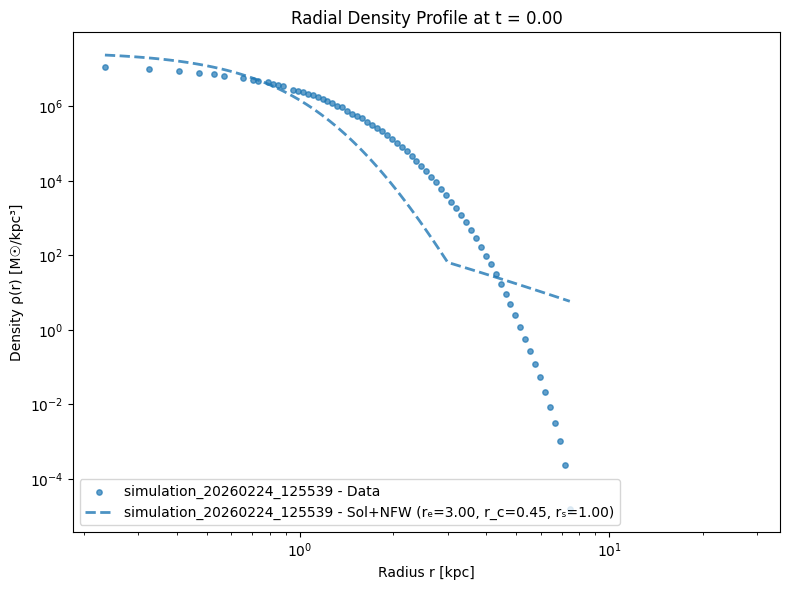

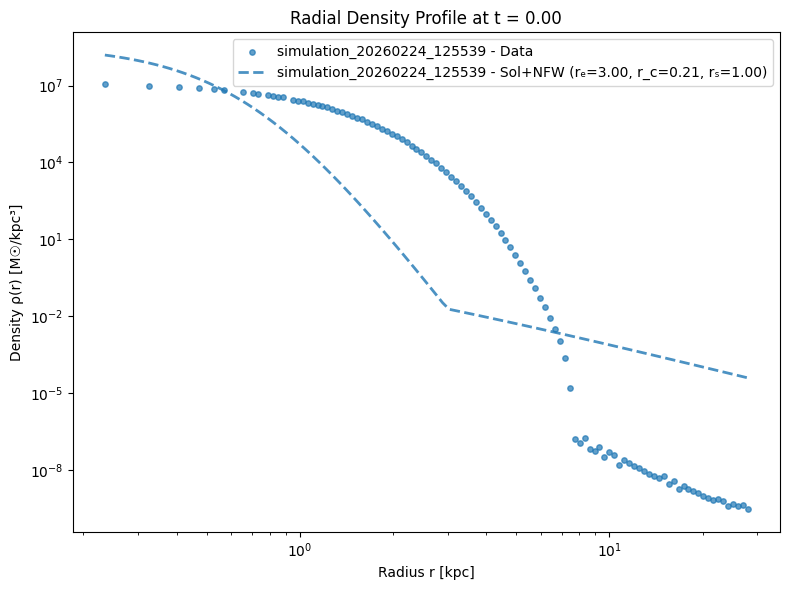

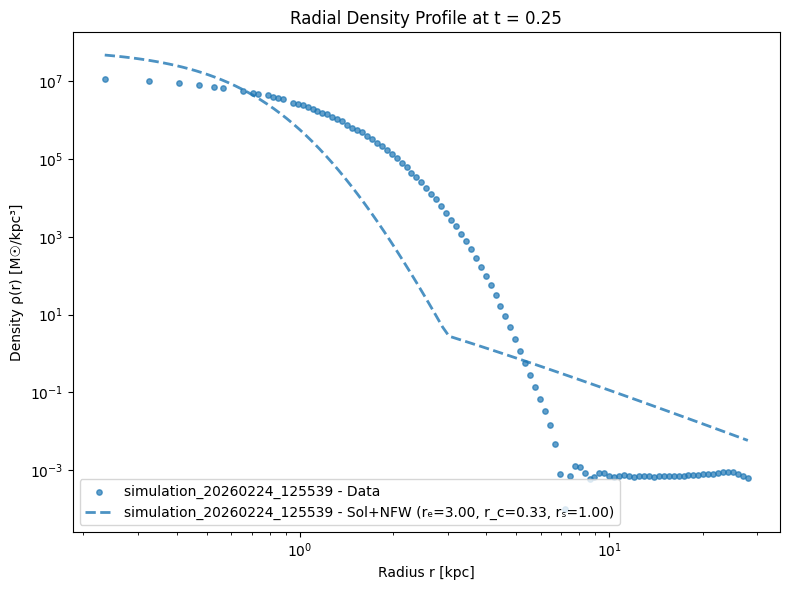

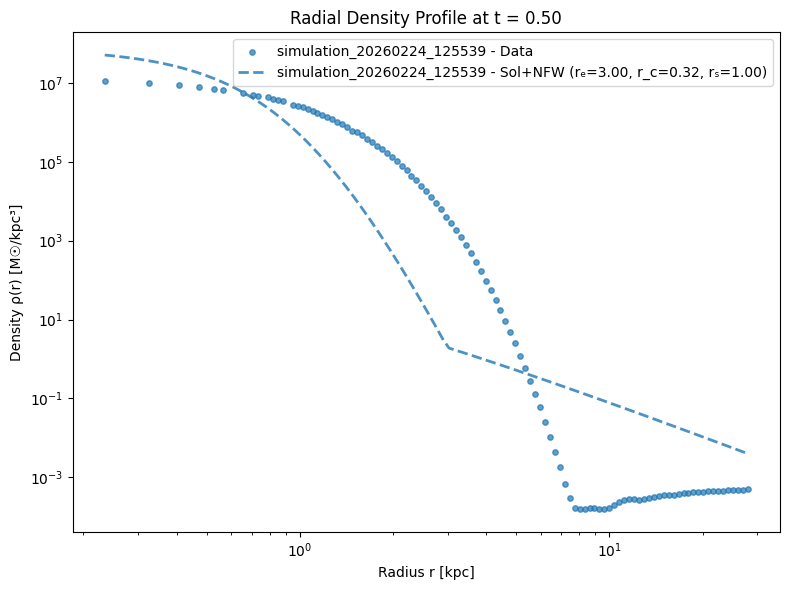

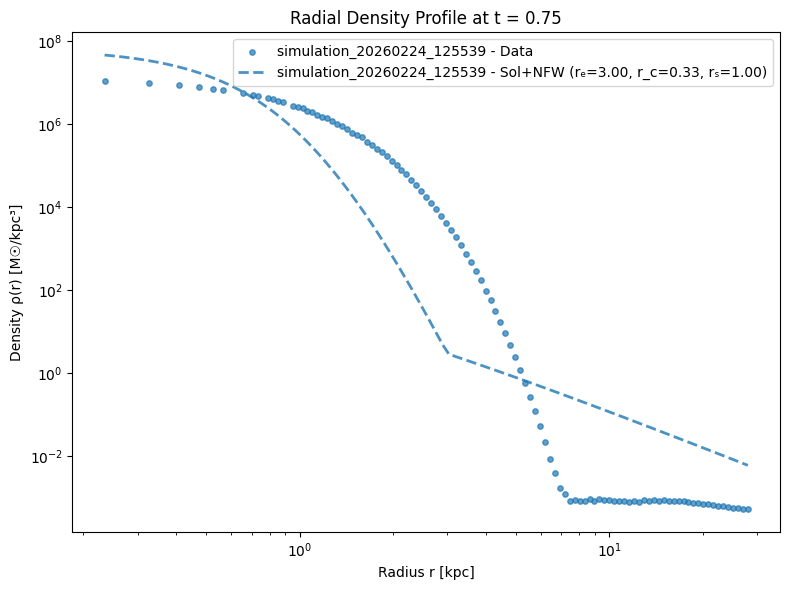

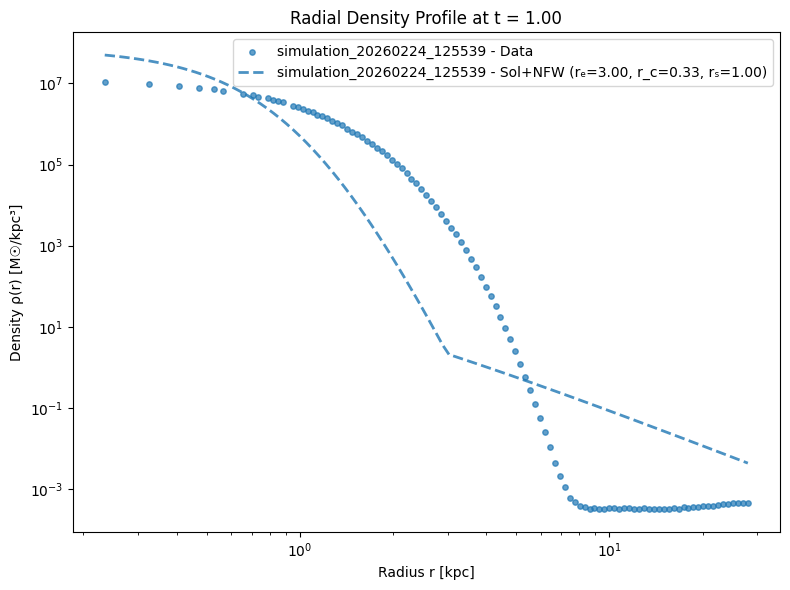

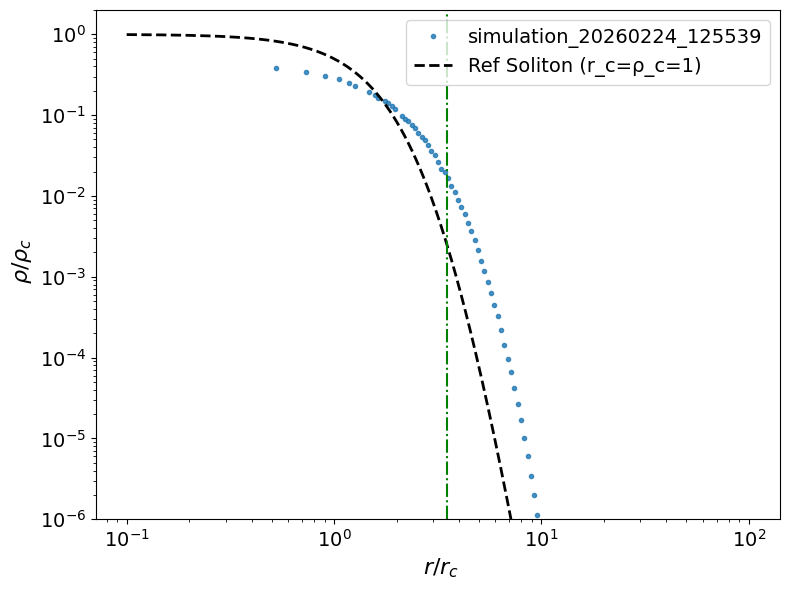

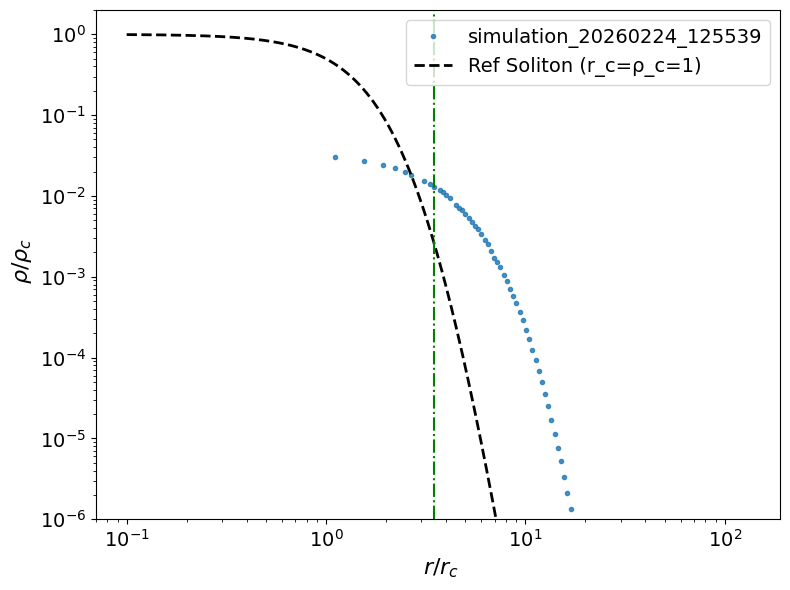

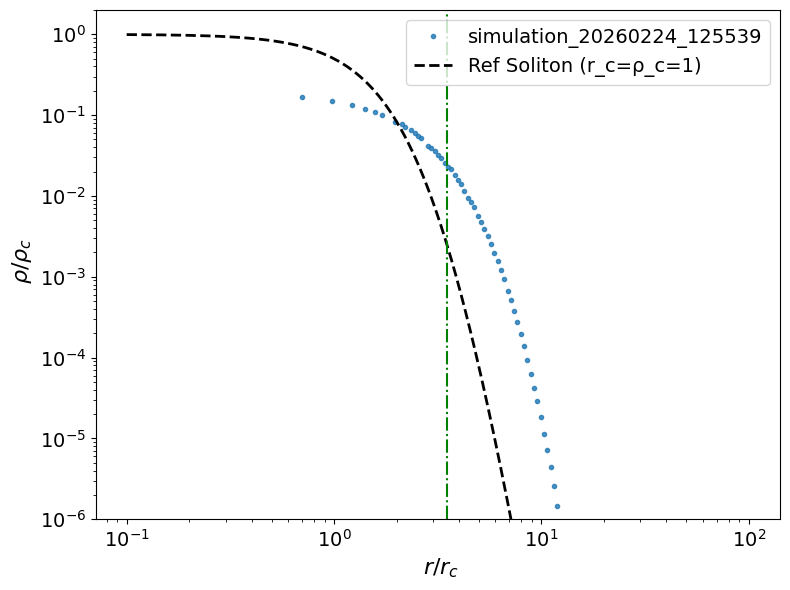

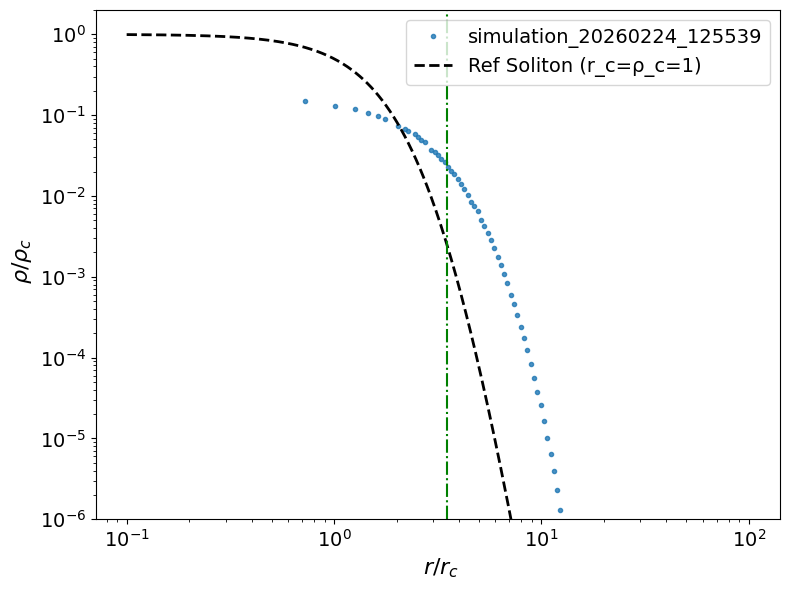

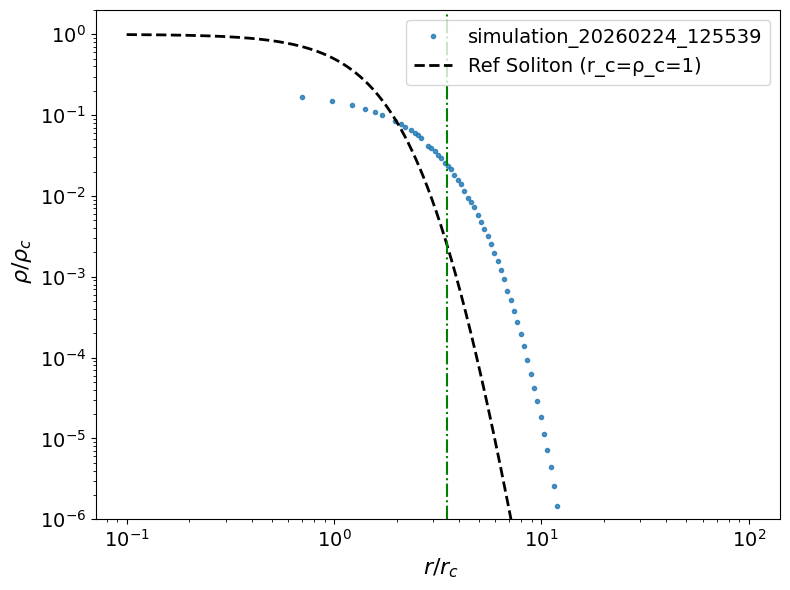

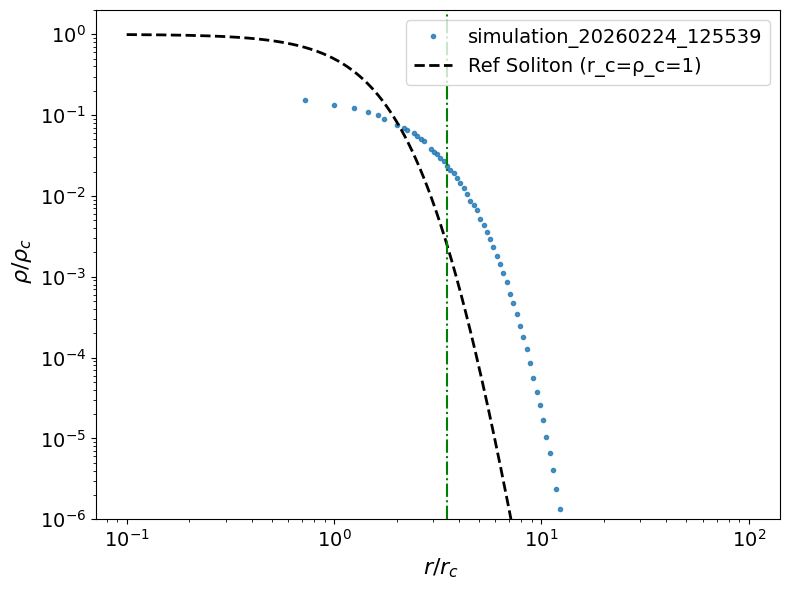

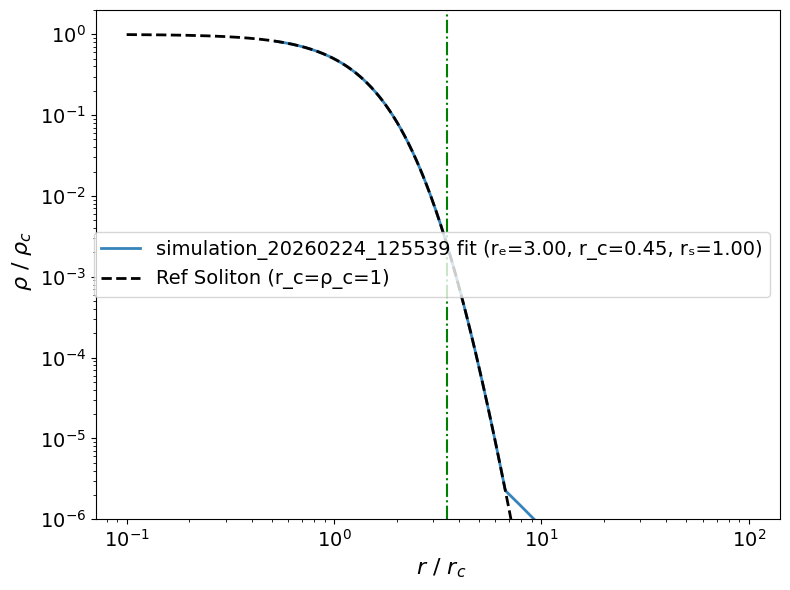

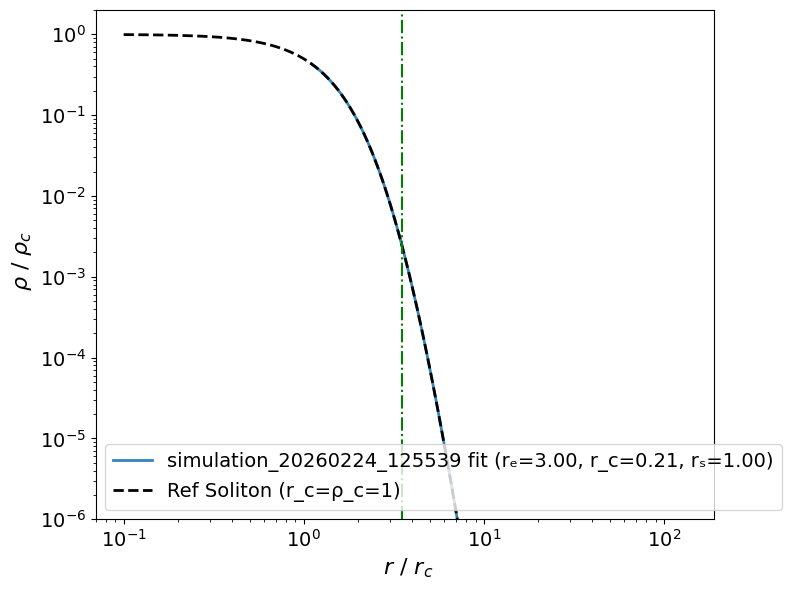

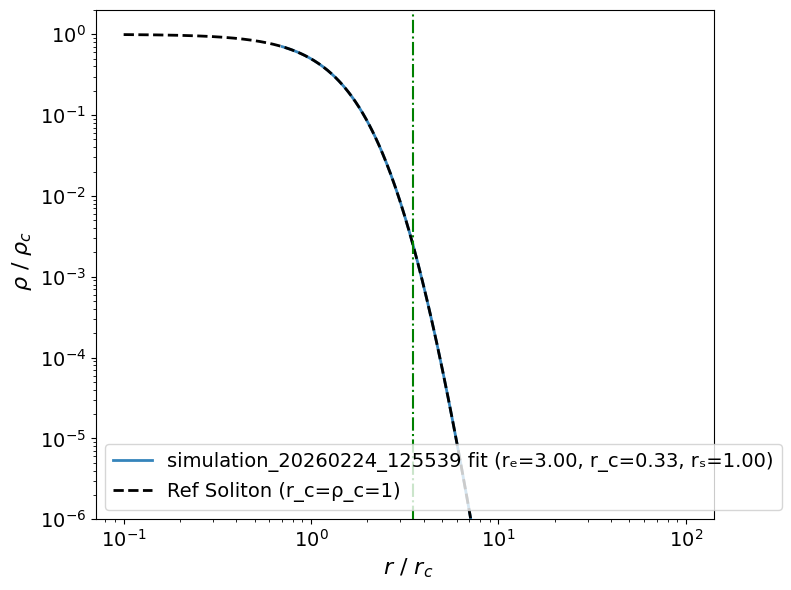

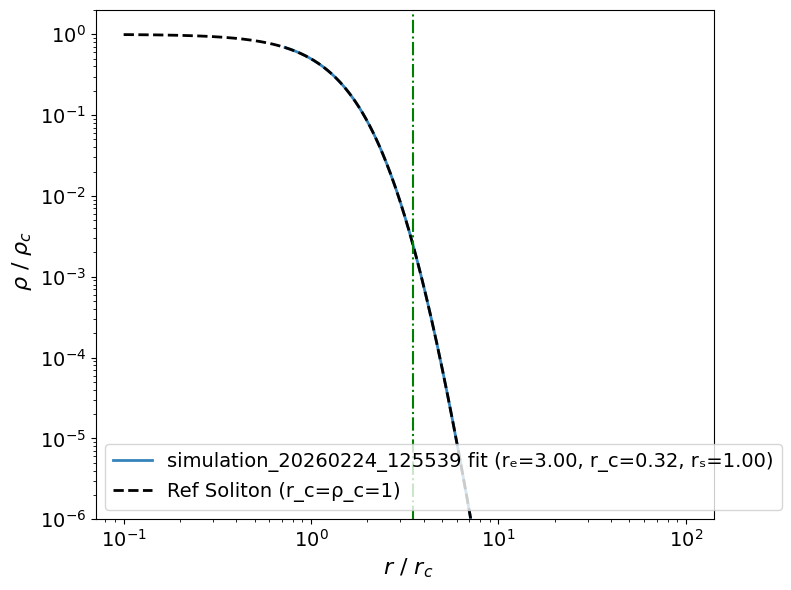

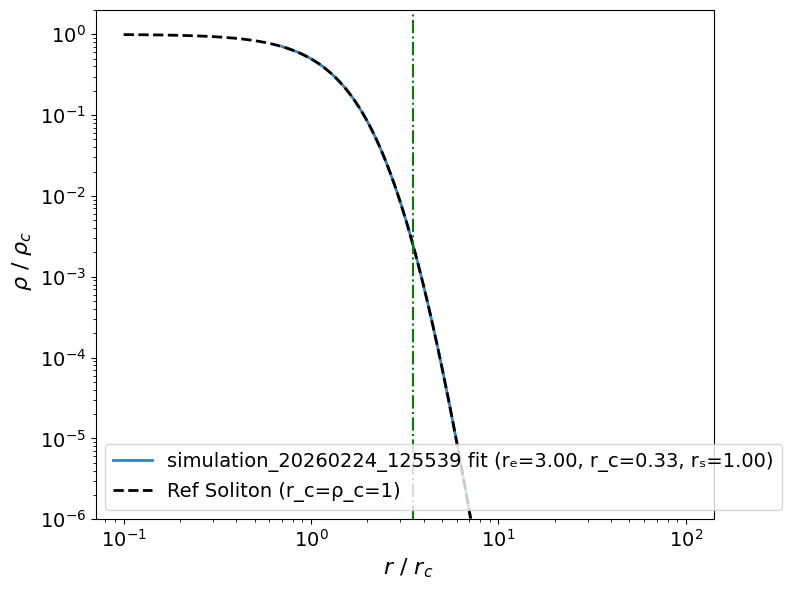

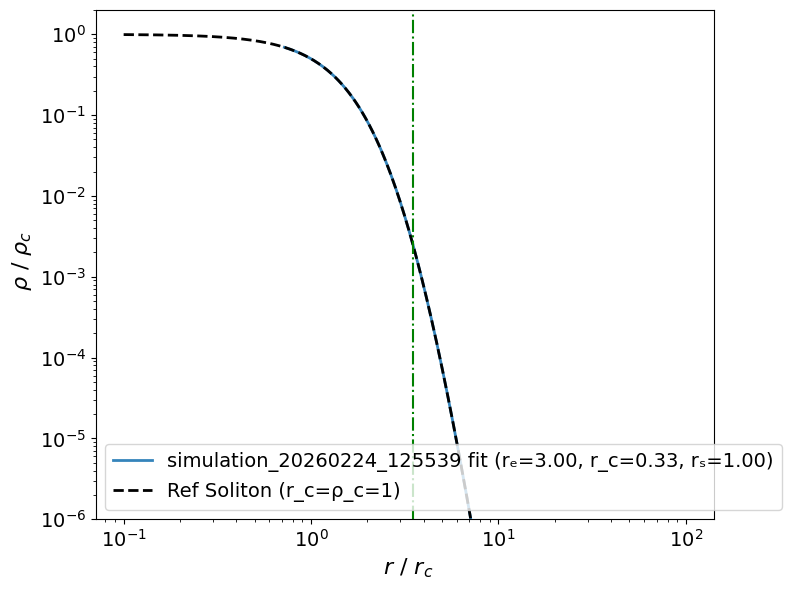

<Figure size 640x480 with 0 Axes>

In [48]:
%run plot_density.py

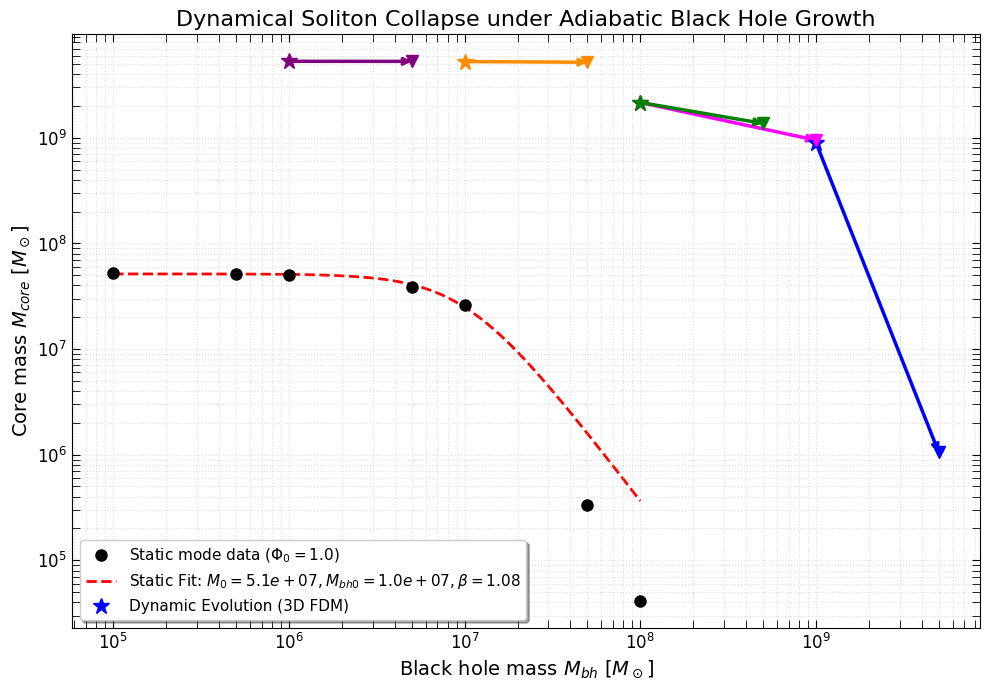

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definice fitovací funkce
def erick_fit(M_bh, M_0, M_bh0, beta):
    return M_0 / (1 + (M_bh / M_bh0)**2)**beta

# 2. Načtení dat
# Tvoje statická data pro Phi0 = 1.0 (pozadí)
file_static = "soliton_radii_data_ms2522_phi1.csv"
df_static = pd.read_csv(file_static).sort_values(by='M_bh')

# Tvoje nová dynamická data z tabulky
file_dynamic = "soliton_mass_drop_phi1.csv"
df_dyn = pd.read_csv(file_dynamic)

# Vypočítáme konečnou hmotnost solitonu z dynamiky
df_dyn['M_core_end'] = df_dyn['M_core_start'] - df_dyn['Observed_mass_drop']

# 3. Příprava grafu
plt.figure(figsize=(10, 7))

# --- A. VYKRESLENÍ STATICKÉHO POZADÍ (Černé tečky) ---
plt.plot(df_static['M_bh'], df_static['Msol'], marker='o', ms=8, color='black', ls='', label=r'Static mode data ($\Phi_0 = 1.0$)')

# --- B. VYKRESLENÍ ERICKOVA FITU (Červená přerušovaná čára) ---
p0 = [df_static['Msol'].max(), 5e6, 1.0]
popt, _ = curve_fit(erick_fit, df_static['M_bh'], df_static['Msol'], p0=p0, bounds=(0, np.inf), maxfev=10000)

x_fit = np.logspace(np.log10(df_static['M_bh'].min()), np.log10(df_static['M_bh'].max()), 100)
y_fit = erick_fit(x_fit, *popt)

eq = fr'Static Fit: $M_0={popt[0]:.1e}, M_{{bh0}}={popt[1]:.1e}, \beta={popt[2]:.2f}$'
plt.plot(x_fit, y_fit, color='red', ls='--', lw=2, zorder=1, label=eq)

# --- C. VYKRESLENÍ TVÝCH DYNAMICKÝCH SIMULACÍ (Barevné šipky) ---
# Použijeme barvy, aby šipky vynikly
colors = ['blue', 'magenta', 'green', 'darkorange', 'purple']

for i, row in df_dyn.iterrows():
    x_start = row['M_bh_start']
    y_start = row['M_core_start']
    x_end = row['M_bh_end']
    y_end = row['M_core_end']
    
    # Nakreslíme počáteční bod (hvězdička)
    label_dyn = "Dynamic Evolution (3D FDM)" if i == 0 else ""
    plt.plot(x_start, y_start, marker='*', color=colors[i % len(colors)], ms=12, ls='', zorder=3, label=label_dyn)
    
    # Nakreslíme šipku ukazující dynamický kolaps
    plt.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                 arrowprops=dict(arrowstyle="->", color=colors[i % len(colors)], lw=2.5, shrinkA=0, shrinkB=0),
                 zorder=2)
    
    # Zakončení šipky (kam to spadlo)
    plt.plot(x_end, y_end, marker='v', color=colors[i % len(colors)], ms=8, ls='', zorder=3)

# 4. Formátování grafu
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Black hole mass $M_{bh} \ [M_\odot]$', fontsize=14)
plt.ylabel(r'Core mass $M_{core} \ [M_\odot]$', fontsize=14)
plt.title("Dynamical Soliton Collapse under Adiabatic Black Hole Growth", fontsize=16)

plt.tick_params(axis='both', which='both', direction='in', length=6, right=True, top=True, labelsize=12)
plt.legend(fontsize=11, frameon=True, shadow=True)
plt.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()

# 5. Zobrazení a uložení
plt.savefig("Dynamical_Soliton_Collapse_Plot.png", dpi=300)
plt.show()

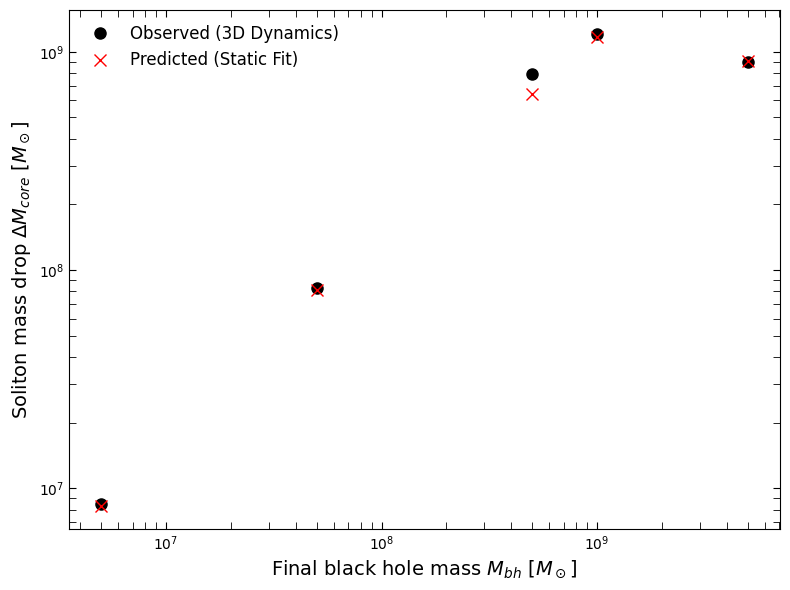

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Načtení tvých dat
df_dyn = pd.read_csv("soliton_mass_drop_phi1.csv")

plt.figure(figsize=(8, 6))

# Vykreslení Observed vs Predicted na stejnou X osu
plt.plot(df_dyn['M_bh_end'], df_dyn['Observed_mass_drop'], 
         marker='o', ms=8, color='black', ls='', label='Observed (3D Dynamics)')

plt.plot(df_dyn['M_bh_end'], df_dyn['Predicted_mass_drop'], 
         marker='x', ms=8, color='red', ls='', label='Predicted (Static Fit)')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Final black hole mass $M_{bh} \ [M_\odot]$', fontsize=14)
plt.ylabel(r'Soliton mass drop $\Delta M_{core} \ [M_\odot]$', fontsize=14)

# Tvůj čistý styl (žádný grid, žádný title, ticky dovnitř ze všech stran)
plt.tick_params(axis='both', which='both', direction='in', length=5, right=True, top=True)
plt.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig("plots/soliton_masses/predicted_vs_observed_mass_drop.png", format='png', dpi=600, bbox_inches='tight')
plt.show()


In [19]:
import pandas as pd

# 1. Načtení dat
csv_filename = "resources/solitons/phi1/soliton_data_ms2522_ph.csv"
df = pd.read_csv(csv_filename)

df_cleaned = df.drop([]).reset_index(drop=True)

df_cleaned.to_csv(csv_filename, index=False)


print("Opravená tabulka:")
display(df_cleaned)

Opravená tabulka:


,M_bh,m_scalar_eV,Mhalo,Msol_target,Msol,soliton_radius,soliton_mass_radius
0,1000000.0,2.500000e-22,3.922368e+11,3.660043e+08,50145540.00,0.662913,1.048157
1,100000.0,2.500000e-22,8.879471e+10,2.230655e+08,52793836.00,0.110941,0.000000
2,10000.0,2.500000e-22,2.010138e+10,1.359498e+08,53060430.00,0.182950,0.182950
3,10000000.0,2.500000e-22,1.732645e+12,6.005372e+08,26378490.00,0.020590,0.000000
4,30000000.0,2.500000e-22,3.519896e+12,7.605830e+08,1386102.80,0.000854,0.000000
5,50000000.0,2.500000e-22,4.893934e+12,8.488990e+08,333321.38,0.000184,0.000000
6,70000000.0,2.500000e-22,6.080429e+12,9.126020e+08,119675.52,0.000061,0.000000


hbartilde 7.842780153469577


hbartilde 7.842780153469577
=== Initial state ===
Initial total mass       = 2.1754639792240535e+01
Initial blob center      = 5.00000000
Initial peak position    = 5.00000000

=== Final state ===
Final total mass         = 2.1754639792240532e+01
Relative mass error      = 1.6330832009765964e-16

Final blob center        = 0.00293207
Expected blob center     = -0.00000000
Blob-center error        = 0.00293207

Final peak position      = 0.23437500
Expected peak position   = 0.00000000
Peak-position error      = 0.23437500

L1 error vs exact shift  = 6.75305800e-03
L2 error vs exact shift  = 1.84263978e-02


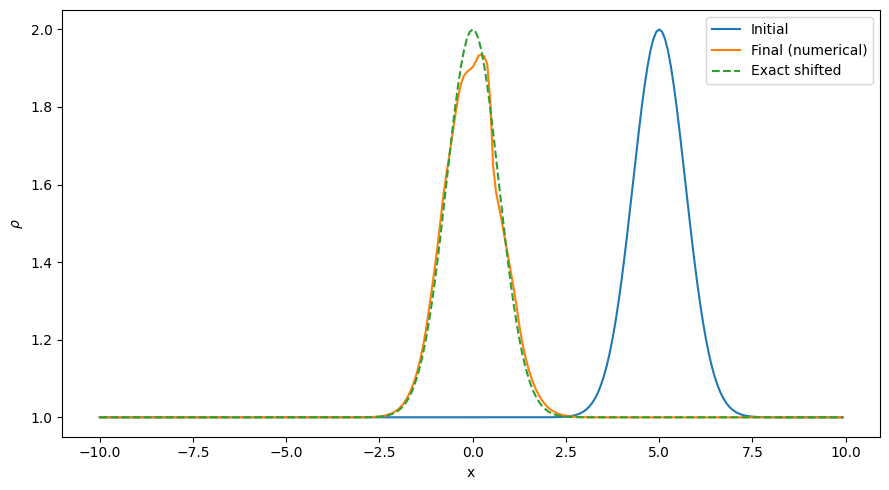

In [13]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt


# =========================================================
# Helper functions
# =========================================================

def periodic_shifted_coords(x, shift, xmin, xmax):
    """
    Return coordinates corresponding to x shifted by 'shift'
    on a periodic domain [xmin, xmax).
    """
    L = xmax - xmin
    return xmin + ((x - shift - xmin) % L)


def blob_center(x, rho, rho_bg):
    """
    Center of the overdensity blob: uses delta rho = rho - rho_bg.
    This is the correct quantity to track when the gas has a nonzero background.
    """
    drho = rho - rho_bg
    mass_blob = cp.sum(drho)
    return float((cp.sum(x * drho) / mass_blob).get())


def peak_position(x, rho, rho_bg):
    """
    Position of the peak of the overdensity blob.
    """
    drho = rho - rho_bg
    idx = int(cp.argmax(drho).get())
    return float(x[idx].get()), idx


def l1_error(a, b):
    return float(cp.mean(cp.abs(a - b)).get())


def l2_error(a, b):
    return float(cp.sqrt(cp.mean((a - b) ** 2)).get())


# =========================================================
# Simulation parameters
# =========================================================

xmin, xmax = -10.0, 10.0
N = 256

t_end = 1
h = 0.02

vx_uniform = -5.0
cs = 0.5
gamma = 5.0 / 3.0
cfl = 0.4

rho_bg = 1.0
A = 1.0
x0 = 5.0
sigma = 0.7

# ---------------------------------------------------------
# Build simulation
# ---------------------------------------------------------

sim = Simulation_Class(
    dim=1,
    boundaries=[(xmin, xmax)],
    N=N,
    total_time=t_end,
    h=h,
    use_gravity=False,
    use_sponge=False,

)

x = cp.asarray(sim.grids[0])

# =========================================================
# Initial condition: smooth density blob + uniform velocity
# =========================================================

rho0 = rho_bg + A * cp.exp(-0.5 * ((x - x0) / sigma) ** 2)
vx0 = vx_uniform * cp.ones_like(rho0)

gas = NBodyGas(
    simulation=sim,
    rho=rho0,
    vx=vx0,
    cs=cs,
    cfl=cfl,
    gamma=gamma,
)

# Save initial state for comparison
rho_init = gas.rho.copy()

# =========================================================
# Initial diagnostics
# =========================================================

m0 = gas.total_mass()
x_blob_0 = blob_center(x, gas.rho, rho_bg)
x_peak_0, idx_peak_0 = peak_position(x, gas.rho, rho_bg)

print("=== Initial state ===")
print(f"Initial total mass       = {m0:.16e}")
print(f"Initial blob center      = {x_blob_0:.8f}")
print(f"Initial peak position    = {x_peak_0:.8f}")
print()

# =========================================================
# Time integration
# =========================================================

t = 0.0
zero_force = cp.zeros_like(gas.rho)

while t < sim.total_time - 1e-14:
    dt = min(sim.h, sim.total_time - t)

    # No gravity: pass zero accelerations
    gas.drift(dt, (zero_force, zero_force, zero_force))

    t += dt

# =========================================================
# Final diagnostics
# =========================================================

mf = gas.total_mass()
x_blob_f = blob_center(x, gas.rho, rho_bg)
x_peak_f, idx_peak_f = peak_position(x, gas.rho, rho_bg)

# Expected shift after t_end
shift = vx_uniform * t_end

# For this setup: x0 = 5, vx = -5, t=1 => expected center ~ 0
x_blob_expected = x_blob_0 + shift
x_peak_expected = x_peak_0 + shift

# Analytic translated profile on periodic domain
x_shifted = periodic_shifted_coords(x, shift=shift, xmin=xmin, xmax=xmax)
rho_exact = rho_bg + A * cp.exp(-0.5 * ((x_shifted - x0) / sigma) ** 2)

mass_rel_err = abs(mf - m0) / abs(m0)
blob_center_err = x_blob_f - x_blob_expected
peak_err = x_peak_f - x_peak_expected
err_L1 = l1_error(gas.rho, rho_exact)
err_L2 = l2_error(gas.rho, rho_exact)

print("=== Final state ===")
print(f"Final total mass         = {mf:.16e}")
print(f"Relative mass error      = {mass_rel_err:.16e}")
print()

print(f"Final blob center        = {x_blob_f:.8f}")
print(f"Expected blob center     = {x_blob_expected:.8f}")
print(f"Blob-center error        = {blob_center_err:.8f}")
print()

print(f"Final peak position      = {x_peak_f:.8f}")
print(f"Expected peak position   = {x_peak_expected:.8f}")
print(f"Peak-position error      = {peak_err:.8f}")
print()

print(f"L1 error vs exact shift  = {err_L1:.8e}")
print(f"L2 error vs exact shift  = {err_L2:.8e}")

# =========================================================
# Plot
# =========================================================

x_cpu = cp.asnumpy(x)
rho_init_cpu = cp.asnumpy(rho_init)
rho_final_cpu = cp.asnumpy(gas.rho)
rho_exact_cpu = cp.asnumpy(rho_exact)

plt.figure(figsize=(9, 5))
plt.plot(x_cpu, rho_init_cpu, label="Initial")
plt.plot(x_cpu, rho_final_cpu, label="Final (numerical)")
plt.plot(x_cpu, rho_exact_cpu, "--", label="Exact shifted")
plt.xlabel("x")
plt.ylabel(r"$\rho$")

plt.legend()
plt.tight_layout()
plt.savefig("plots/movement_test/gas_movement",dpi=300)
plt.show()
